In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
odds =pd.read_parquet("data/processed/odds.parquet")
point_by_point =pd.read_parquet("data/processed/point_by_point.parquet")
statistics =pd.read_parquet("data/processed/statistics.parquet")
tennis_power =pd.read_parquet("data/processed/tennis_power.parquet")
votes =pd.read_parquet("data/processed/votes.parquet")
MatchAwayScoreInfo=pd.read_parquet("data/processed/match_away_score_info.parquet")
MatchHomeScoreInfo=pd.read_parquet("data/processed/match_home_score_info.parquet")
MatchEventInfo=pd.read_parquet("data/processed/match_event_info.parquet")
MatchAwayTeamInfo=pd.read_parquet("data/processed/MatchAwayTeamInfo.parquet")
MatchHomeTeamInfo=pd.read_parquet("data/processed/MatchHomeTeamInfo.parquet")
MatchRoundInfo=pd.read_parquet("data/processed/MatchRoundInfo.parquet")
MatchSeasonInfo=pd.read_parquet("data/processed/MatchSeasonInfo.parquet")
MatchTimeInfo=pd.read_parquet("data/processed/MatchTimeInfo.parquet")
MatchTournamentInfo=pd.read_parquet("data/processed/MatchTournamentInfo.parquet")
MatchVenueInfo=pd.read_parquet("data/processed/MatchVenueInfo.parquet")

# Question 1

Total Unique Players: 2644

Gender Counts
gender
M    1404
F    1234
Name: count, dtype: int64

Gender Percentages
gender
M    53.22
F    46.78
Name: proportion, dtype: float64


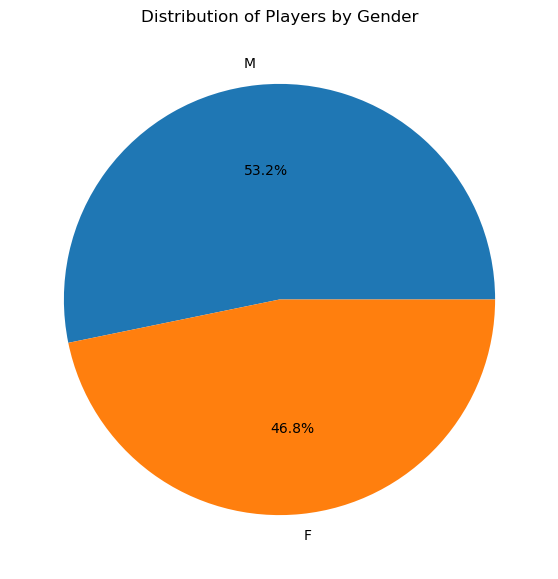

In [50]:
# Create a table of unique players
home_players = MatchHomeTeamInfo[['player_id', 'gender']]
away_players = MatchAwayTeamInfo[['player_id', 'gender']]

players = pd.concat(
    [home_players, away_players],
        ignore_index=True
        )

players = players.drop_duplicates(subset='player_id')
        

#General statistics
total_players = len(players)

gender_counts = players['gender'].value_counts()

gender_percent = (
    players['gender']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("=" * 50)
print(f"Total Unique Players: {total_players}")

print("\nGender Counts")
print(gender_counts)

print("\nGender Percentages")
print(gender_percent)

# Pie Chart


plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title("Distribution of Players by Gender")

plt.show()


In [32]:
gender_summary = pd.DataFrame({
    'Count': gender_counts,
    'Percentage': gender_percent
})

display(gender_summary)

,Count,Percentage
gender,,
M,1404,53.22
F,1234,46.78


# Question 2

In [44]:
# Create a data frame of unique players with height, gender, and ranking information
home = MatchHomeTeamInfo[['player_id', 'gender', 'height', 'current_rank']]
away = MatchAwayTeamInfo[['player_id', 'gender', 'height', 'current_rank']]

players = pd.concat([home, away], ignore_index=True)

players = players.drop_duplicates(subset='player_id')

players = players.dropna(subset=['height'])

print("Unique Players:", len(players))

Unique Players: 1317


In [43]:
#Average height of all players and by gender
print("="*50)
print("Overall Average Height")
print("="*50)

print(players['height'].mean())

print("\nAverage Height by Gender")
print("="*50)

print(
    players.groupby('gender')['height']
           .agg(['count','mean','median','std','min','max'])
)

Overall Average Height
1.8213743356112377

Average Height by Gender
        count      mean  median       std   min   max
gender                                               
F         256  1.732227    1.73  0.061409  1.57  1.90
M        1060  1.842943    1.85  0.069150  1.57  2.08


<Figure size 800x600 with 0 Axes>

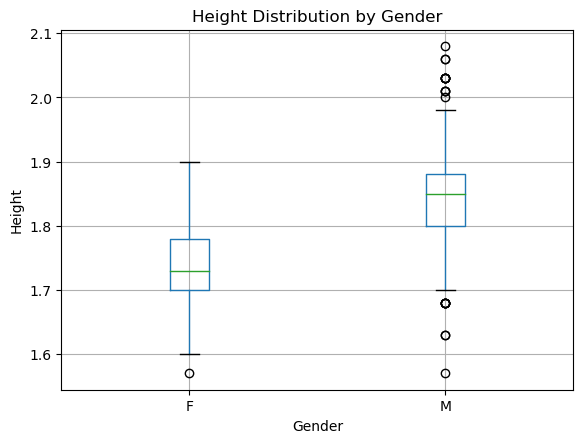

In [ ]:
#Draw a box plot of the distribution of height data by gender:
plt.figure(figsize=(8,6))

players.boxplot(
    column='height',
    by='gender'
)

plt.title('Height Distribution by Gender')
plt.suptitle('')
plt.xlabel('Gender')
plt.ylabel('Height')

plt.show()

In [46]:
#Examining the relationship between height and ranking by gender of players Ranking data is inversely related to ability or superiority.
#This means that the lower an individual's ranking, the more successful the player.
rank_height = players.dropna(
    subset=['height', 'current_rank', 'gender']
)

for gender in sorted(rank_height['gender'].unique()):

    subset = rank_height[
        rank_height['gender'] == gender
    ]

    corr = subset['height'].corr(
        subset['current_rank']
    )

    print(f"{gender}: {corr:.3f}")

F: -0.187
M: -0.109


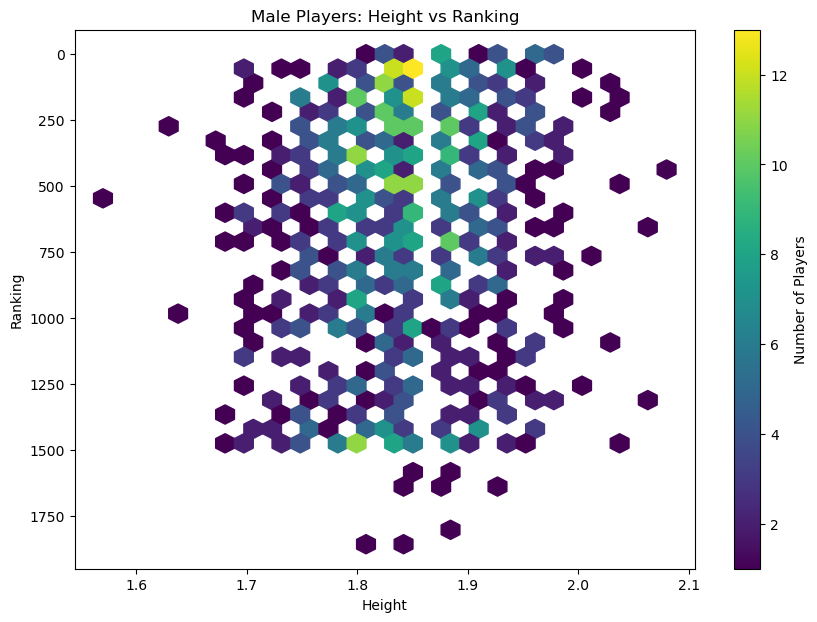

In [47]:
#Drawing a hexagonal data density diagram to examine the relationship between height and ranking of male players
male = rank_height[
    rank_height['gender'] == 'M'
]

plt.figure(figsize=(10,7))

plt.hexbin(
    male['height'],
    male['current_rank'],
    gridsize=30,
    mincnt=1
)

plt.gca().invert_yaxis()

plt.xlabel('Height')
plt.ylabel('Ranking')
plt.title('Male Players: Height vs Ranking')

cb = plt.colorbar()
cb.set_label('Number of Players')

plt.show()

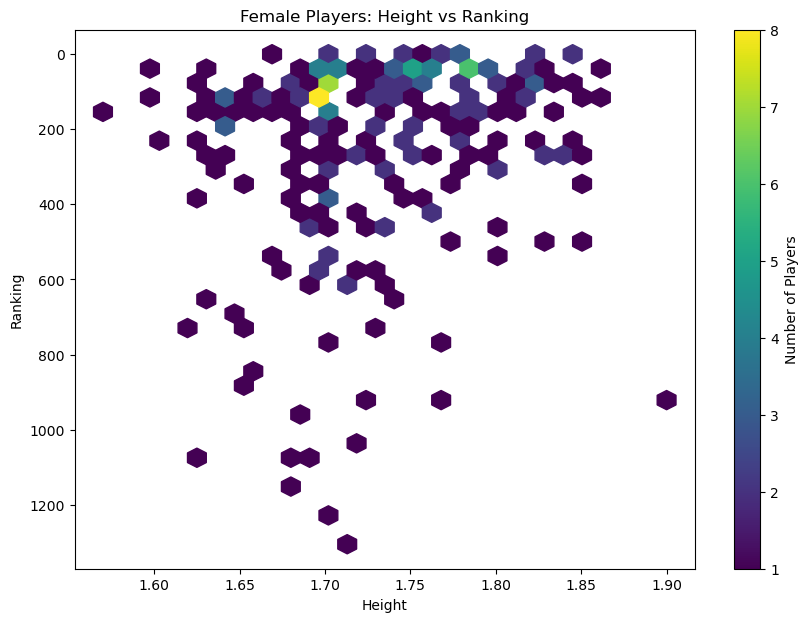

In [48]:
#Drawing a hexagonal data density diagram to examine the relationship between height and ranking of female players
female = rank_height[
    rank_height['gender'] == 'F'
]

plt.figure(figsize=(10,7))

plt.hexbin(
    female['height'],
    female['current_rank'],
    gridsize=30,
    mincnt=1
)

plt.gca().invert_yaxis()

plt.xlabel('Height')
plt.ylabel('Ranking')
plt.title('Female Players: Height vs Ranking')

cb = plt.colorbar()
cb.set_label('Number of Players')

plt.show()

# Question 3

In [39]:
matches = (
    MatchEventInfo[['match_id', 'winner_code']]
    .merge(
        MatchHomeTeamInfo[
            ['match_id', 'player_id', 'full_name', 'gender']
        ],
        on='match_id'
    )
    .merge(
        MatchAwayTeamInfo[
            ['match_id', 'player_id', 'full_name', 'gender']
        ],
        on='match_id',
        suffixes=('_home', '_away')
    )
)

In [40]:
home_results = pd.DataFrame({
    'player_id': matches['player_id_home'],
    'player_name': matches['full_name_home'],
    'gender': matches['gender_home'],
    'win': (matches['winner_code'] == 1).astype(int),
    'loss': (matches['winner_code'] == 2).astype(int)
})

away_results = pd.DataFrame({
    'player_id': matches['player_id_away'],
    'player_name': matches['full_name_away'],
    'gender': matches['gender_away'],
    'win': (matches['winner_code'] == 2).astype(int),
    'loss': (matches['winner_code'] == 1).astype(int)
})

In [41]:
player_results = pd.concat(
    [home_results, away_results],
    ignore_index=True
)

player_stats = (
    player_results
    .groupby(
        ['player_id', 'player_name', 'gender'],
        as_index=False
    )
    .agg(
        wins=('win', 'sum'),
        losses=('loss', 'sum')
    )
)

player_stats['matches'] = (
    player_stats['wins']
    + player_stats['losses']
)

player_stats['win_rate'] = (
    player_stats['wins']
    / player_stats['matches']
)

In [42]:
player_stats["win_rate"].max()

1.0

In [49]:
#More players with fewer than 50 games
#have a success rate of one. But by setting a minimum of 50 games,
#active players with the highest success rate will be introduced.
qualified = player_stats[
    player_stats['matches'] >= 50
]

In [51]:
best_winrate = (
    qualified
    .sort_values(
        ['gender', 'win_rate'],
        ascending=[True, False]
    )
    .groupby('gender')
    .head(1)
)

best_winrate[
    [
        'gender',
        'player_name',
        'wins',
        'losses',
        'win_rate'
    ]
]

,gender,player_name,wins,losses,win_rate
2209,F,"Valentova, Tereza",127,0,1.000000
2043,M,"Faria, Jaime",261,16,0.942238


#### Question 22: the best underdog players

In [52]:
# In the last part of the answer to this question, we will examine the winnings of weak players, which
# are the players who have won the most while the odds of prediction and betting
# predict their losses.
def fractional_to_decimal(x):
    try:
        num, den = x.split('/')
        return float(num) / float(den)
    except:
        return None

odds['odds_value'] = odds['fractional_value'].apply(
    fractional_to_decimal
)

In [53]:
odds[['fractional_value','odds_value']].head()

,fractional_value,odds_value
0,1/5,0.200000
1,10/3,3.333333
2,14/1,14.000000
3,3/100,0.030000
4,4/5,0.800000


In [55]:
#To check the number of wins with low probability, we only need the win-loss comparison market
winner_odds = odds[
    (odds['market_name'] == 'full_time')
    &
    (odds['choice_name'].isin(['1','2']))
].copy()

In [56]:
winner_odds['choice_name'].value_counts()

choice_name
1    22210
2    22210
Name: count, dtype: int64

In [57]:
odds_match = (
    winner_odds
    .pivot_table(
        index='match_id',
        columns='choice_name',
        values='odds_value',
        aggfunc='first'
    )
    .reset_index()
)

In [71]:
#It can be seen that in the created frame, only the match_id and the probability of the host and guest winning columns
# exist, which allows for comparison.
print(odds_match.columns)

Index(['match_id', 'home_odds', 'away_odds', 'underdog_side'], dtype='object', name='choice_name')


In [59]:
odds_match = odds_match.rename(
    columns={
        '1':'home_odds',
        '2':'away_odds'
    }
)

In [60]:
odds_match.head()

choice_name,match_id,home_odds,away_odds
0,11974049,0.33,2.250000
1,11974052,0.36,2.000000
2,11974053,0.20,3.333333
3,11974065,0.05,10.000000
4,11974066,14.00,0.030000


In [61]:

odds_match['underdog_side'] = np.where(
    odds_match['home_odds']
    >
    odds_match['away_odds'],
    1,
    2
)

In [72]:
#Delete matches without a winner
matches = matches.dropna(
    subset=['winner_code']
)

In [64]:
matches = (
    MatchEventInfo[['match_id','winner_code']]
    .merge(
        MatchHomeTeamInfo[
            ['match_id','player_id','full_name','gender']
        ],
        on='match_id'
    )
    .merge(
        MatchAwayTeamInfo[
            ['match_id','player_id','full_name','gender']
        ],
        on='match_id',
        suffixes=('_home','_away')
    )
)

In [65]:
underdog_matches = matches.merge(
    odds_match,
    on='match_id',
    how='inner'
)

In [73]:
#Betting on matches where the underdog, or the player with the lowest odds of winning, is the winner
underdog_wins = underdog_matches[
    underdog_matches['winner_code']
    ==
    underdog_matches['underdog_side']
].copy()

In [ ]:
print(len(underdog_wins))

27830


In [68]:
underdog_winners = []

for _, row in underdog_wins.iterrows():

    if row['winner_code'] == 1:

        underdog_winners.append({
            'player_id': row['player_id_home'],
            'player_name': row['full_name_home'],
            'gender': row['gender_home']
        })

    else:

        underdog_winners.append({
            'player_id': row['player_id_away'],
            'player_name': row['full_name_away'],
            'gender': row['gender_away']
        })

underdog_winners = pd.DataFrame(
    underdog_winners
)

In [69]:
underdog_stats = (
    underdog_winners
    .groupby(
        ['player_id','player_name','gender']
    )
    .size()
    .reset_index(
        name='underdog_wins'
    )
)

In [75]:
#Finally, the 10 players with the most unpredicted wins, broken down by gender.
top10_underdogs = (
    underdog_stats
    .sort_values(
        ['gender','underdog_wins'],
        ascending=[True,False]
    )
    .groupby('gender')
    .head(10)
)

display(top10_underdogs)

,player_id,player_name,gender,underdog_wins
954,288576,"Noha Akugue, Noma",F,113
1140,348987,"Bartůňková, Nikola",F,97
1062,318258,"Berecoechea, Nahia",F,95
78,42839,"Barthel, Mona",F,86
605,199509,"Lamens, Suzan",F,83
133,51839,"Alves, Carolina",F,80
982,293868,"Kudermetova, Polina",F,78
276,88318,"Albie, Audrey",F,70
1053,313796,"Maklakova, Ekaterina",F,70
498,165866,"Miyazaki, Yuriko Lily",F,67


# Question 4

In [77]:
#Get the columns for each set
period_cols = sorted(
    [
        col
        for col in MatchTimeInfo.columns
        if col.startswith("period_")
    ]
)

period_cols

['period_1', 'period_2', 'period_3', 'period_4', 'period_5']

In [78]:
#Calculate the length of each set
MatchTimeInfo["duration_sec"] = (
    MatchTimeInfo[period_cols]
    .fillna(0)
    .sum(axis=1)
)

MatchTimeInfo["duration_min"] = (
    MatchTimeInfo["duration_sec"] / 60
)

MatchTimeInfo["duration_hr"] = (
    MatchTimeInfo["duration_sec"] / 3600
)

In [79]:
#Number of sets per match
MatchTimeInfo["num_sets"] = (
    MatchTimeInfo[period_cols]
    .notna()
    .sum(axis=1)
)

In [80]:
point_counts = (
    point_by_point
    .groupby("match_id")
    .size()
    .reset_index(name="total_points")
)
valid_matches = (
    MatchTimeInfo
    .merge(
        point_counts,
        on="match_id",
        how="inner"
    )
)
valid_matches["sec_per_point"] = (
    valid_matches["duration_sec"]
    / valid_matches["total_points"]
)

In [81]:
#To calculate outliers, we use the median absolute deviation or MAD calculation.
median_spp = (
    valid_matches["sec_per_point"]
    .median()
)

mad_spp = (
    valid_matches["sec_per_point"]
    .sub(median_spp)
    .abs()
    .median()
)

In [82]:
#robust z
valid_matches["robust_z"] = (
    0.6745
    * (
        valid_matches["sec_per_point"]
        - median_spp
    )
    / mad_spp
)

In [83]:
valid_matches_before_filter = (
    valid_matches.copy()
)

In [84]:
#Now we filter out suspicious matches
valid_matches = (
    valid_matches[
        valid_matches["robust_z"] <= 5
    ]
    .copy()
)

In [86]:
gender_df = (
    pd.concat([
        MatchHomeTeamInfo[
            ["match_id", "gender"]
        ],
        MatchAwayTeamInfo[
            ["match_id", "gender"]
        ]
    ])
    .dropna()
    .drop_duplicates("match_id")
)

In [87]:
if "gender" not in valid_matches.columns:
    
    valid_matches = valid_matches.merge(
        gender_df,
        on="match_id",
        how="left"
    )

In [88]:
#Longest men's tournament
longest_men = (
    valid_matches[
        valid_matches["gender"] == "M"
    ]
    .sort_values(
        "duration_hr",
        ascending=False
    )
    .drop_duplicates("match_id")
)

longest_men[
    [
        "match_id",
        "duration_hr",
        "total_points",
        "num_sets",
        "sec_per_point"
    ]
].head(10)

,match_id,duration_hr,total_points,num_sets,sec_per_point
2959,12056393,4.953889,420,3,42.461905
20284,12194086,4.501667,534,3,30.348315
21434,12201395,4.424722,530,3,30.054717
16563,12163362,4.306944,432,3,35.891204
4571,12063596,4.145000,340,3,43.888235
19585,12159529,4.093611,408,3,36.120098
4217,12064963,4.085556,486,3,30.263374
18382,12172807,3.915278,422,3,33.400474
6116,12082586,3.867500,380,3,36.639474
14781,12152339,3.813611,484,3,28.365702


In [89]:
#Longest woman's tournament
longest_women = (
    valid_matches[
        valid_matches["gender"] == "F"
    ]
    .sort_values(
        "duration_hr",
        ascending=False
    )
    .drop_duplicates("match_id")
)

longest_women[
    [
        "match_id",
        "duration_hr",
        "total_points",
        "num_sets",
        "sec_per_point"
    ]
].head(10)

,match_id,duration_hr,total_points,num_sets,sec_per_point
15533,12152568,4.346944,356,3,43.957865
20574,12194966,4.233333,484,3,31.487603
10233,12109297,4.221389,360,3,42.213889
6841,12086012,4.142222,478,3,31.196653
17850,12172227,4.101667,362,3,40.790055
13169,12140777,4.049722,681,3,21.408223
18578,12176348,4.013611,462,3,31.274892
3205,12058890,4.003611,333,2,43.282282
20912,12197936,3.799444,492,3,27.800813
20360,12156297,3.751667,364,3,37.104396


# Question 5

In [90]:
MatchTimeInfo["num_sets"] = (
    MatchTimeInfo[
        ["period_1", "period_2", "period_3"]
    ]
    .notna()
    .sum(axis=1)
)

In [92]:
gender_df = (
    pd.concat([
        MatchHomeTeamInfo[["match_id", "gender"]],
        MatchAwayTeamInfo[["match_id", "gender"]]
    ])
    .dropna()
    .drop_duplicates("match_id")
)

In [94]:
sets_df = MatchTimeInfo[
    ["match_id", "num_sets"]
].merge(
    gender_df,
    on="match_id",
    how="left"
)

In [95]:
sets_df.groupby("gender")["num_sets"].agg(
    matches="count",
    mean_sets="mean",
    median_sets="median",
    mode_sets=lambda x: x.mode().iloc[0]
).round(2)

,matches,mean_sets,median_sets,mode_sets
gender,,,,
F,12469,1.72,2.0,2
M,17463,1.62,2.0,2


In [96]:
#Additional Analysis
#Examining the relationship between the number of sets and the probability of winning for a player with a higher ranking.
ranking_df = (
    MatchEventInfo[
        ["match_id", "winner_code"]
    ]
    .merge(
        MatchHomeTeamInfo[
            ["match_id", "current_rank", "gender"]
        ].rename(
            columns={
                "current_rank": "home_rank"
            }
        ),
        on="match_id",
        how="inner"
    )
    .merge(
        MatchAwayTeamInfo[
            ["match_id", "current_rank"]
        ].rename(
            columns={
                "current_rank": "away_rank"
            }
        ),
        on="match_id",
        how="inner"
    )
)

In [97]:
#Delete incomplete records
ranking_df = ranking_df.dropna(
    subset=[
        "home_rank",
        "away_rank",
        "winner_code"
    ]
)

In [99]:
ranking_df["better_rank_player_won"] = np.where(
    ranking_df["home_rank"]
    <
    ranking_df["away_rank"],

    ranking_df["winner_code"] == 1,

    ranking_df["winner_code"] == 2)


In [100]:
ranking_df["better_rank_player_won"].mean()

0.6471672701580853

In [101]:
ranking_df.groupby(
    "gender"
)["better_rank_player_won"].mean().round(3)

gender
F    0.645
M    0.649
Name: better_rank_player_won, dtype: float64

In [103]:
ranking_df = ranking_df.merge(
    MatchTimeInfo[
        ["match_id", "num_sets"]
    ],
    on="match_id",
    how="left"
)

In [104]:
#Table of the probability of winning the top player and the number of sets played
men_sets = (
    ranking_df[
        ranking_df["gender"] == "M"
    ]
    .groupby("num_sets")
    ["better_rank_player_won"]
    .mean()
    .reset_index()
)

men_sets

,num_sets,better_rank_player_won
0,0,0.628746
1,1,0.485623
2,2,0.675495
3,3,0.596283


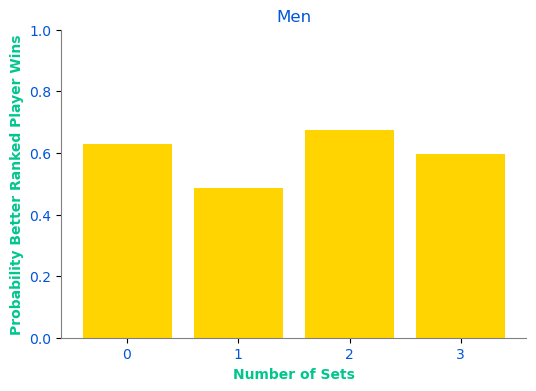

In [142]:

plt.figure(figsize=(6,4))

plt.bar(
    men_sets["num_sets"].astype(str),
    men_sets["better_rank_player_won"],color="#FFD400"
)

plt.xlabel("Number of Sets",color="#00C68D",weight="bold")
plt.ylabel("Probability Better Ranked Player Wins",color="#00C68D",weight="bold")
plt.title("Men",color="#0055DA")
plt.xticks(color="#0055DA")
plt.yticks(color="#0055DA")

plt.ylim(0, 1)
ax=plt.gca()
ax.spines[["top","right"]].set_visible(False)
ax.spines[["bottom","left"]].set_color("gray")

plt.show()

In [109]:
women_sets = (
    ranking_df[
        ranking_df["gender"] == "F"
    ]
    .groupby("num_sets")
    ["better_rank_player_won"]
    .mean()
    .reset_index()
)

women_sets

,num_sets,better_rank_player_won
0,0,0.564283
1,1,0.753582
2,2,0.686986
3,3,0.584995


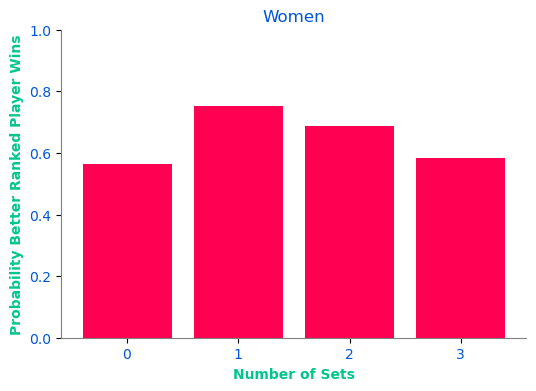

In [141]:
plt.figure(figsize=(6,4))

plt.bar(
    women_sets["num_sets"].astype(str),
    women_sets["better_rank_player_won"],color="#FF0052"
)

plt.xlabel("Number of Sets",color="#00C68D",weight="bold")
plt.ylabel("Probability Better Ranked Player Wins",color="#00C68D",weight="bold")
plt.title("Women",color="#0055DA")
plt.xticks(color="#0055DA")
plt.yticks(color="#0055DA")

plt.ylim(0, 1)
ax=plt.gca()
ax.spines[["top","right"]].set_visible(False)
ax.spines[["bottom","left"]].set_color("gray")
plt.show()

# Question 6

We use three criteria to assess the success of countries.

In [111]:
#First criterion: Country win rate
#Each player has one row
country_players = pd.concat([
    MatchHomeTeamInfo[
        ["match_id", "full_name", "country"]
    ].assign(side=1),

    MatchAwayTeamInfo[
        ["match_id", "full_name", "country"]
    ].assign(side=2)
])

In [112]:
# Determining the winner in each game:
country_players = country_players.merge(
    MatchEventInfo[
        ["match_id", "winner_code"]
    ],
    on="match_id",
    how="inner"
)
country_players["win"] = (
    country_players["side"]
    ==
    country_players["winner_code"]
)

In [113]:
country_winrate = (
    country_players
    .groupby("country")
    .agg(
        matches=("match_id", "count"),
        wins=("win", "sum")
    )
    .reset_index()
)

In [115]:
country_winrate["win_rate"] = (
    country_winrate["wins"]
    /
    country_winrate["matches"]
)
country_winrate[
    country_winrate["matches"] >= 50
].sort_values(
    "win_rate",
    ascending=False
).head(5)

,country,matches,wins,win_rate
69,Norway,356,249,0.699438
25,Dominican Republic,236,155,0.656780
40,Indonesia,53,33,0.622642
55,Lithuania,566,335,0.591873
89,Syria,91,53,0.582418


In [116]:
#Second criterion: Average ranking of players by country
#Players and their rankings:
all_players = pd.concat([
    MatchHomeTeamInfo[
        ["full_name", "country", "current_rank"]
    ],

    MatchAwayTeamInfo[
        ["full_name", "country", "current_rank"]
    ]
])

In [117]:
all_players = (
    all_players
    .dropna(subset=["current_rank"])
    .drop_duplicates("full_name")
)
# Calculate the average ranking of players in each country:
country_rank = (
    all_players
    .groupby("country")
    .agg(
        players=("full_name", "count"),
        avg_rank=("current_rank", "mean")
    )
    .reset_index()
)
country_rank[
    country_rank["players"] >= 5
].sort_values(
    "avg_rank",
    ascending=True
).head(5)

,country,players,avg_rank
88,Tunisia,6,451.666667
38,Hungary,18,466.277778
9,Belgium,29,489.379310
21,Croatia,24,529.791667
15,Canada,27,549.555556


In [118]:
#Criteria 3: Country with the most players in the top 100
#Top 100 players
top100_players = all_players[
    all_players["current_rank"] <= 100
]

In [119]:
country_top100 = (
    top100_players
    .groupby("country")
    .size()
    .reset_index(
        name="top100_players"
    )
)
country_top100.sort_values(
    "top100_players",
    ascending=False
).head(5)

,country,top100_players
36,USA,24
30,Russia,18
16,France,15
33,Spain,11
20,Italy,11


##### Question 23 : the relationship between BMI and player rankings

In [120]:
players = pd.concat([
    MatchHomeTeamInfo[
        ["full_name", "gender", "height", "weight", "current_rank"]
    ],
    MatchAwayTeamInfo[
        ["full_name", "gender", "height", "weight", "current_rank"]
    ]
])

In [121]:
players = (
    players
    .drop_duplicates("full_name")
    .copy()
) 
players = players.dropna(
    subset=[
        "height",
        "weight",
        "current_rank"
    ]
)

In [122]:
#Calculations related to body mass index:
players["bmi"] = (
    players["weight"]
    /
    (players["height"] ** 2)
)

In [123]:
players["bmi"].describe()

count    656.000000
mean      22.477591
std        1.693097
min        8.659560
25%       21.499597
50%       22.540903
75%       23.510204
max       26.551437
Name: bmi, dtype: float64

In [124]:
players[
    players["bmi"] < 15
][
    ["full_name", "gender", "height", "weight", "current_rank", "bmi"]
].sort_values("bmi")

,full_name,gender,height,weight,current_rank,bmi
8207,"Vrbensky, Michael",M,1.83,29.0,310.0,8.659560
24992,"Ferreira Silva, Frederico",M,1.78,34.0,376.0,10.730968


In [125]:
#In the previous cells, it was observed that people with indices 8 and 10 were recorded
#which is probably a data error. So we filter the data to remove the errors.
players = players[
    (players["weight"] >= 45) &
    (players["height"] >= 1.60) &
    (players["bmi"].between(15, 35))
].copy()

In [126]:
players["bmi"].describe()

count    653.000000
mean      22.516992
std        1.540679
min       17.319120
25%       21.502943
50%       22.550941
75%       23.510204
max       26.551437
Name: bmi, dtype: float64

In [ ]:
# Correlation between BMI and ranking of all players
players[
    ["bmi", "current_rank"]
].corr(
    method="spearman"
)

,bmi,current_rank
bmi,1.000000,0.191689
current_rank,0.191689,1.000000


In [129]:
#Correlation between BMI and ranking of men's
men = players[
    players["gender"] == "M"
].copy()
men[
    ["bmi", "current_rank"]
].corr(
    method="spearman"
)

,bmi,current_rank
bmi,1.000000,0.099702
current_rank,0.099702,1.000000


In [131]:
#Correlation between BMI and ranking of women's
women = players[
    players["gender"] == "F"
].copy()
women[
    ["bmi", "current_rank"]
].corr(
    method="spearman"
)

,bmi,current_rank
bmi,1.000000,0.013206
current_rank,0.013206,1.000000


In [133]:
men["bmi_group"] = pd.cut(
    men["bmi"],
    bins=np.arange(17, 28, 0.5)
)
men_bmi_rank = (
    men
    .groupby("bmi_group")
    .agg(
        avg_rank=("current_rank", "mean"),
        count=("current_rank", "count")
    )
    .reset_index()
)

men_bmi_rank

,bmi_group,avg_rank,count
0,"(17.0, 17.5]",NaN,0
1,"(17.5, 18.0]",225.000000,1
2,"(18.0, 18.5]",NaN,0
3,"(18.5, 19.0]",795.500000,2
4,"(19.0, 19.5]",303.857143,7
5,"(19.5, 20.0]",316.000000,8
6,"(20.0, 20.5]",379.733333,15
7,"(20.5, 21.0]",490.142857,21
8,"(21.0, 21.5]",413.400000,40
9,"(21.5, 22.0]",499.155172,58


In [149]:
men_bmi_rank = men_bmi_rank[
    men_bmi_rank["count"] >= 10
].copy()

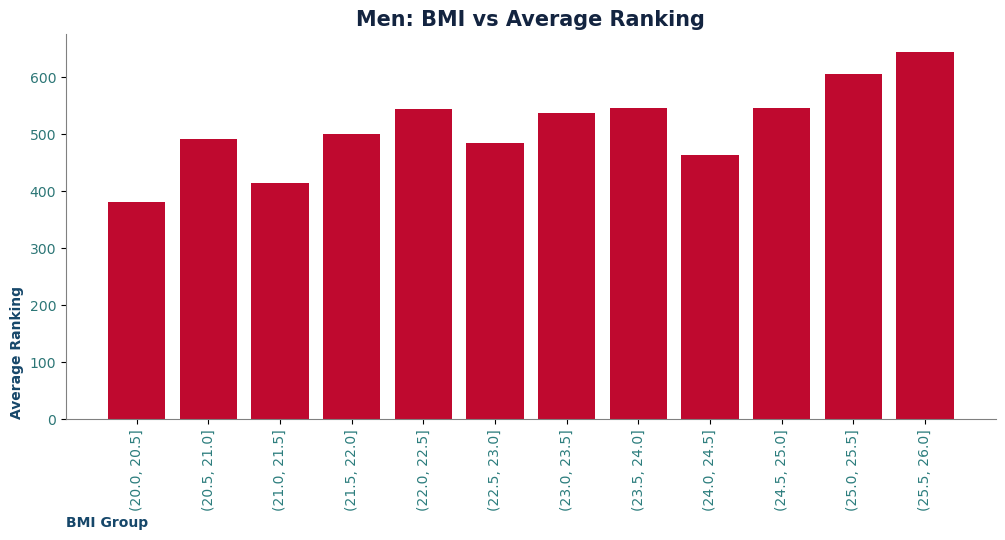

In [150]:
plt.figure(figsize=(12,5))

plt.bar(
    men_bmi_rank["bmi_group"].astype(str),
    men_bmi_rank["avg_rank"],color="#BF092F"
)

plt.xticks(rotation=90,color="#2C7D7D")
plt.yticks(color="#2C7676")

plt.xlabel("BMI Group",weight="bold",loc="left",color="#16476A")
plt.ylabel("Average Ranking",weight="bold",loc="bottom",color="#16476A")
plt.title("Men: BMI vs Average Ranking",fontsize=15,color="#132440",weight="bold")
ax=plt.gca()
ax.spines[["top","right"]].set_visible(False)
ax.spines[["bottom","left"]].set_color("gray")
plt.show()

In [151]:
women["bmi_group"] = pd.cut(
    women["bmi"],
    bins=np.arange(17, 28, 0.5)
)
women_bmi_rank = (
    women
    .groupby("bmi_group")
    .agg(
        avg_rank=("current_rank", "mean"),
        count=("current_rank", "count")
    )
    .reset_index()
)

women_bmi_rank

,bmi_group,avg_rank,count
0,"(17.0, 17.5]",82.000000,1
1,"(17.5, 18.0]",272.000000,1
2,"(18.0, 18.5]",725.500000,2
3,"(18.5, 19.0]",39.000000,1
4,"(19.0, 19.5]",131.444444,9
5,"(19.5, 20.0]",285.600000,10
6,"(20.0, 20.5]",186.181818,11
7,"(20.5, 21.0]",209.187500,16
8,"(21.0, 21.5]",262.944444,18
9,"(21.5, 22.0]",146.800000,10


In [152]:
women_bmi_rank = women_bmi_rank[
    women_bmi_rank["count"] >= 5
].copy()

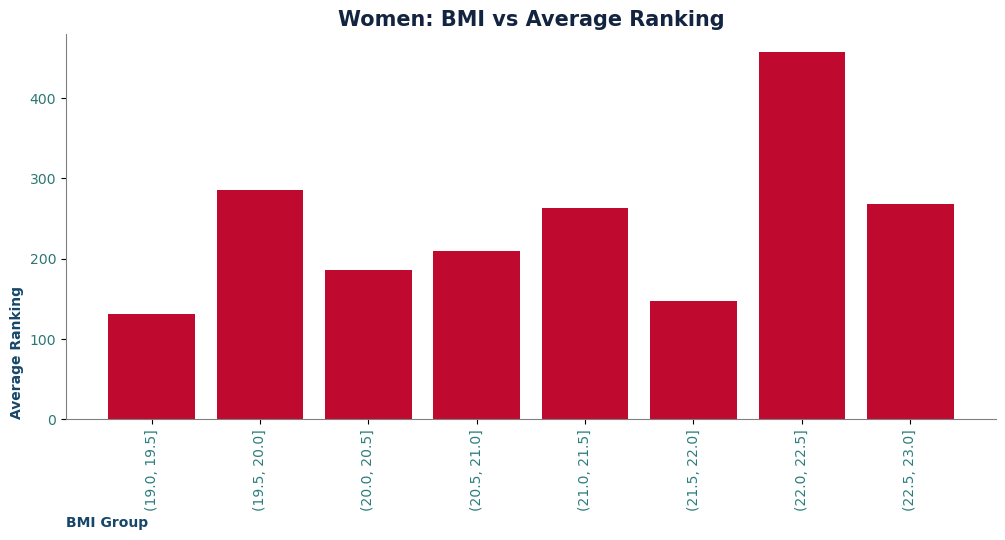

In [154]:
plt.figure(figsize=(12,5))

plt.bar(
    women_bmi_rank["bmi_group"].astype(str),
    women_bmi_rank["avg_rank"],color="#BF092F"
)

plt.xticks(rotation=90,color="#2C7D7D")
plt.yticks(color="#2C7676")

plt.xlabel("BMI Group",weight="bold",loc="left",color="#16476A")
plt.ylabel("Average Ranking",weight="bold",loc="bottom",color="#16476A")
plt.title("Women: BMI vs Average Ranking",fontsize=15,color="#132440",weight="bold")
ax=plt.gca()
ax.spines[["top","right"]].set_visible(False)
ax.spines[["bottom","left"]].set_color("gray")
plt.show()

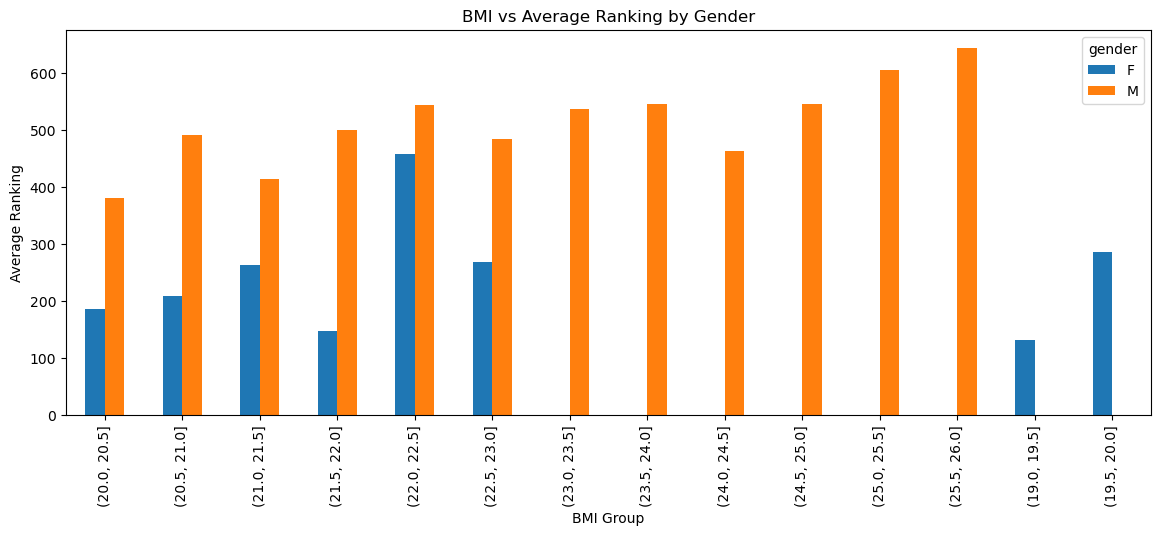

In [156]:
#Comparative chart for women and men
comparison = pd.concat([
    men_bmi_rank.assign(gender="M"),
    women_bmi_rank.assign(gender="F")
])
pivot_df = comparison.pivot(
    index="bmi_group",
    columns="gender",
    values="avg_rank"
)

pivot_df.plot(
    kind="bar",
    figsize=(14,5)
)

plt.xlabel("BMI Group")
plt.ylabel("Average Ranking")
plt.title("BMI vs Average Ranking by Gender")

plt.show()

# Question 7

In [8]:
statistics[statistics.astype(str).apply(lambda row:row.str.contains("aces",case=False).any(),axis=1)].head()

,match_id,period,statistic_category_name,statistic_name,home_stat,away_stat,compare_code,statistic_type,value_type,home_value,away_value,home_total,away_total,date
0,11998445,ALL,service,aces,12,6,1,positive,event,12,6,NaN,NaN,20240201
20,11998445,1ST,service,aces,2,3,2,positive,event,2,3,NaN,NaN,20240201
37,11998445,2ND,service,aces,6,3,1,positive,event,6,3,NaN,NaN,20240201
54,11998445,3RD,service,aces,4,0,1,positive,event,4,0,NaN,NaN,20240201
71,11998446,ALL,service,aces,6,3,1,positive,event,6,3,NaN,NaN,20240201


The dataset contains four period categories:

- **1ST** — First period
- **2ND** — Second period
- **3RD** — Third period
- **ALL** — Total of the 1st, 2nd, and 3rd periods

For this analysis, we will filter the dataset and keep only the records where the period is **ALL**.

In [20]:
aces= statistics[(statistics["statistic_name"].str.lower() == "aces") & (statistics["period"]=="ALL")].copy()
aces

,match_id,period,statistic_category_name,statistic_name,home_stat,away_stat,compare_code,statistic_type,value_type,home_value,away_value,home_total,away_total,date
0,11998445,ALL,service,aces,12,6,1,positive,event,12,6,NaN,NaN,20240201
71,11998446,ALL,service,aces,6,3,1,positive,event,6,3,NaN,NaN,20240201
125,11998447,ALL,service,aces,8,4,1,positive,event,8,4,NaN,NaN,20240201
178,11998448,ALL,service,aces,4,0,1,positive,event,4,0,NaN,NaN,20240201
232,11998449,ALL,service,aces,6,4,1,positive,event,6,4,NaN,NaN,20240201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1357965,12213482,ALL,service,aces,0,1,2,positive,event,0,1,NaN,NaN,20240331
1358019,12213483,ALL,service,aces,0,0,3,positive,event,0,0,NaN,NaN,20240331
1358073,12213484,ALL,service,aces,1,0,1,positive,event,1,0,NaN,NaN,20240331
1358127,12213486,ALL,service,aces,0,1,2,positive,event,0,1,NaN,NaN,20240331


In [46]:
aces["home_value"] = pd.to_numeric(aces["home_value"], errors="coerce")
aces["away_value"] = pd.to_numeric(aces["away_value"], errors="coerce")

In [22]:
aces.duplicated().sum()

0

In [28]:
ace_check = aces.groupby("match_id").agg(
    rows=("match_id", "size"),
    home_values=("home_value", "nunique"),
    away_values=("away_value", "nunique")
)

ace_check.sort_values("rows", ascending=False).head(20)

,rows,home_values,away_values
match_id,,,
12063583,4,1,1
12063599,4,1,1
12063611,4,1,1
12063615,4,1,1
12063589,4,1,1
12063588,4,1,1
12063587,4,1,1
12195781,4,1,1
12063582,4,1,1


In this step, we check each `match_id` to see how many times it is repeated.
For each `match_id`, we also check the number of **unique (`nunique`) values** for:
- `home_value`
- `away_value`
This helps us identify whether each match has one unique home value and one unique away value, or whether there are multiple different values for the same match.

In [29]:
problem_aces = ace_check[
    (ace_check["home_values"] > 1) |
    (ace_check["away_values"] > 1)
]

print("Matches with different ace values:", len(problem_aces))
problem_aces.head()

Matches with different ace values: 1126


,rows,home_values,away_values
match_id,,,
12056874,2,2,1
12058641,2,2,2
12058688,2,2,1
12058689,2,1,2
12058702,2,1,2


In [31]:
aces[aces["match_id"] == 12056874].T

,199921,214324
match_id,12056874,12056874
period,ALL,ALL
statistic_category_name,service,service
statistic_name,aces,aces
home_stat,0,1
away_stat,0,0
compare_code,3,1
statistic_type,positive,positive
value_type,event,event
home_value,0,1


it's example to understand which columns can be different when match_id and home_value and away_value are the same. in this case `date` and `compare_code` and `home_value` are different.

In [43]:
aces[["home_value", "away_value"]].isna().sum()

home_value    0
away_value    0
dtype: int64

In [45]:
aces["date"] = pd.to_datetime(aces["date"])
aces[["match_id", "home_value", "away_value", "date"]].head()

,match_id,home_value,away_value,date
0,11998445,12,6,2024-02-01
71,11998446,6,3,2024-02-01
125,11998447,8,4,2024-02-01
178,11998448,4,0,2024-02-01
232,11998449,6,4,2024-02-01


In [47]:
latest_date = aces.groupby("match_id")["date"].transform("max")
aces_latest = aces[aces["date"] == latest_date].copy()

In [48]:
print("Latest-date rows:", len(aces_latest))
print("Unique matches:", aces_latest["match_id"].nunique())

Latest-date rows: 11389
Unique matches: 11389


The most reasonable rule is to keep the record with the latest date, but I would verify that assumption first.

In [49]:
latest_duplicates = aces_latest[aces_latest["match_id"].duplicated(keep=False)]

print("Rows with repeated match_id:", len(latest_duplicates))
print("Matches repeated:",latest_duplicates["match_id"].nunique())

Rows with repeated match_id: 0
Matches repeated: 0


In [52]:
aces_final=(aces_latest.drop_duplicates(subset="match_id").copy())
aces_final["total_aces"]=(aces_final["home_value"]+aces_final["away_value"])
aces_final[["match_id","home_value","away_value","total_aces"]].head()

,match_id,home_value,away_value,total_aces
178,11998448,4,0,4
232,11998449,6,4,10
286,11998450,16,10,26
356,11998451,7,5,12
802,11998672,4,9,13


In [54]:
average_aces=aces_final["total_aces"].mean()
print(f"Average number of aces per match: {average_aces:.2f}")

Average number of aces per match: 5.39


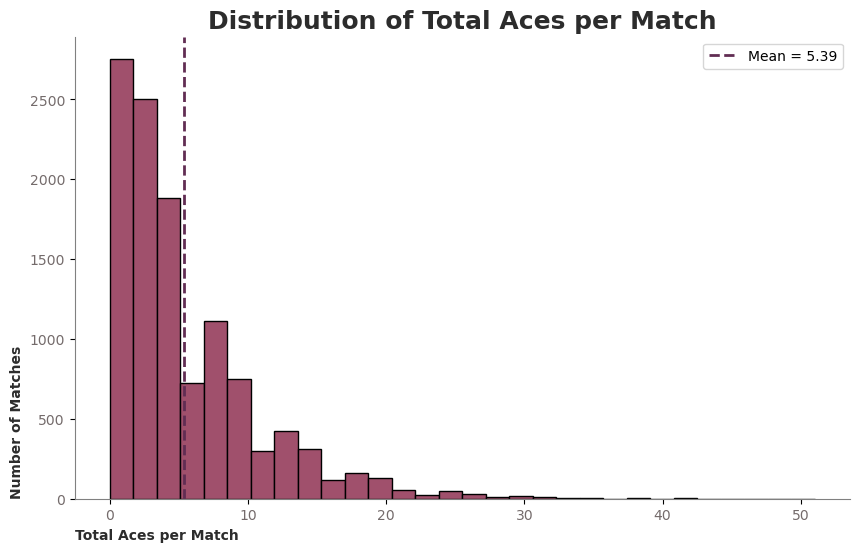

In [65]:
plt.figure(figsize=(10,6))
plt.hist(aces_final["total_aces"],color="#A0506C",bins=30,edgecolor="black")
plt.axvline(average_aces,linestyle="--",linewidth=2,color="#612D53",label=f"Mean = {average_aces:.2f}")
plt.xlabel("Total Aces per Match",loc="left",color="#2C2C2C",weight="bold")
plt.ylabel("Number of Matches",loc="bottom",color="#2C2C2C",weight="bold")
plt.xticks(color="#746B6B")
plt.yticks(color="#746B6B")
plt.title("Distribution of Total Aces per Match",color="#2C2C2C",weight="bold",fontsize=18)
ax=plt.gca()
ax.spines[["top","right"]].set_visible(False)
ax.spines[["bottom","left"]].set_color("gray")
plt.legend()
plt.show()

# Question 8

In [51]:
statistics[statistics["statistic_name"].str.contains("fault",case=False,na=False)]["statistic_name"].unique()

array(['double_faults'], dtype=object)

In [52]:
statistics[statistics.astype(str).apply(lambda row:row.str.contains("double_faults",case=False).any(),axis=1)].head()

,match_id,period,statistic_category_name,statistic_name,home_stat,away_stat,compare_code,statistic_type,value_type,home_value,away_value,home_total,away_total,date
1,11998445,ALL,service,double_faults,2,7,2,negative,event,2,7,NaN,NaN,20240201
21,11998445,1ST,service,double_faults,1,2,2,negative,event,1,2,NaN,NaN,20240201
38,11998445,2ND,service,double_faults,1,2,2,negative,event,1,2,NaN,NaN,20240201
55,11998445,3RD,service,double_faults,0,3,2,negative,event,0,3,NaN,NaN,20240201
72,11998446,ALL,service,double_faults,2,1,1,negative,event,2,1,NaN,NaN,20240201


In [53]:
faults = statistics[(statistics["statistic_name"]=="double_faults")&
                          (statistics["period"]=="ALL")].copy()
faults

,match_id,period,statistic_category_name,statistic_name,home_stat,away_stat,compare_code,statistic_type,value_type,home_value,away_value,home_total,away_total,date
1,11998445,ALL,service,double_faults,2,7,2,negative,event,2,7,NaN,NaN,20240201
72,11998446,ALL,service,double_faults,2,1,1,negative,event,2,1,NaN,NaN,20240201
126,11998447,ALL,service,double_faults,0,5,2,negative,event,0,5,NaN,NaN,20240201
179,11998448,ALL,service,double_faults,2,2,3,negative,event,2,2,NaN,NaN,20240201
233,11998449,ALL,service,double_faults,2,3,2,negative,event,2,3,NaN,NaN,20240201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1357966,12213482,ALL,service,double_faults,0,6,2,negative,event,0,6,NaN,NaN,20240331
1358020,12213483,ALL,service,double_faults,2,4,2,negative,event,2,4,NaN,NaN,20240331
1358074,12213484,ALL,service,double_faults,2,7,2,negative,event,2,7,NaN,NaN,20240331
1358128,12213486,ALL,service,double_faults,1,13,2,negative,event,1,13,NaN,NaN,20240331


In [54]:
fault_check = faults.groupby("match_id").agg(
    rows=("match_id", "size"),
    home_values=("home_value", "nunique"),
    away_values=("away_value", "nunique")
)

fault_check.sort_values("rows", ascending=False).head(20)

,rows,home_values,away_values
match_id,,,
12063583,4,1,1
12063599,4,1,1
12063611,4,1,1
12063615,4,1,1
12063589,4,1,1
12063588,4,1,1
12063587,4,1,1
12195781,4,1,1
12063582,4,1,1


In [55]:
faults["home_value"] = pd.to_numeric(faults["home_value"], errors="coerce")
faults["away_value"] = pd.to_numeric(faults["away_value"], errors="coerce")
faults["date"] = pd.to_datetime(faults["date"])

In [56]:
double_faults_final=(faults.sort_values(["match_id","date"]).drop_duplicates(subset="match_id",keep="last").copy())
print("Rows:", len(double_faults_final))
print("Unique matches:",double_faults_final["match_id"].nunique())

Rows: 11389
Unique matches: 11389


In [57]:
home_gender = MatchHomeTeamInfo[
    ["match_id", "gender"]
].drop_duplicates()

away_gender = MatchAwayTeamInfo[
    ["match_id", "gender"]
].drop_duplicates()

gender_check = home_gender.merge(
    away_gender,
    on="match_id",
    suffixes=("_home", "_away")
)
df_double = double_faults_final.merge(gender_check,on="match_id",how="left")
df_double

,match_id,period,statistic_category_name,statistic_name,home_stat,away_stat,compare_code,statistic_type,value_type,home_value,away_value,home_total,away_total,date,gender_home,gender_away
0,11998445,ALL,service,double_faults,2,7,2,negative,event,2,7,NaN,NaN,2024-02-02,M,M
1,11998446,ALL,service,double_faults,2,1,1,negative,event,2,1,NaN,NaN,2024-02-02,M,M
2,11998447,ALL,service,double_faults,0,5,2,negative,event,0,5,NaN,NaN,2024-02-02,M,M
3,11998448,ALL,service,double_faults,2,2,3,negative,event,2,2,NaN,NaN,2024-02-01,M,M
4,11998449,ALL,service,double_faults,2,3,2,negative,event,2,3,NaN,NaN,2024-02-01,M,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11384,12213482,ALL,service,double_faults,0,6,2,negative,event,0,6,NaN,NaN,2024-03-31,NaN,NaN
11385,12213483,ALL,service,double_faults,2,4,2,negative,event,2,4,NaN,NaN,2024-03-31,NaN,NaN
11386,12213484,ALL,service,double_faults,2,7,2,negative,event,2,7,NaN,NaN,2024-03-31,NaN,NaN
11387,12213486,ALL,service,double_faults,1,13,2,negative,event,1,13,NaN,NaN,2024-03-31,NaN,NaN


In [93]:
home_players = df_double[["match_id", "gender_home", "home_value"]].copy()
home_players.columns = ["match_id", "gender", "double_faults"]

away_players = df_double[["match_id", "gender_away", "away_value"]].copy()
away_players.columns = ["match_id", "gender", "double_faults"]

In [97]:
double_faults_gender = pd.concat([home_players, away_players],ignore_index=True)
double_faults_gender = double_faults_gender.dropna(subset=["gender", "double_faults"])
result=(double_faults_gender.groupby("gender")["double_faults"].agg(["count","mean","median","std"]))
result

,count,mean,median,std
gender,,,,
F,7906,3.506324,3.0,2.843775
M,10046,2.696695,2.0,2.274905


Female players recorded a higher average number of double faults (3.51) than male players (2.70). The median was also higher for females (3 vs. 2), suggesting that double faults tend to be more frequent among female players in this dataset.

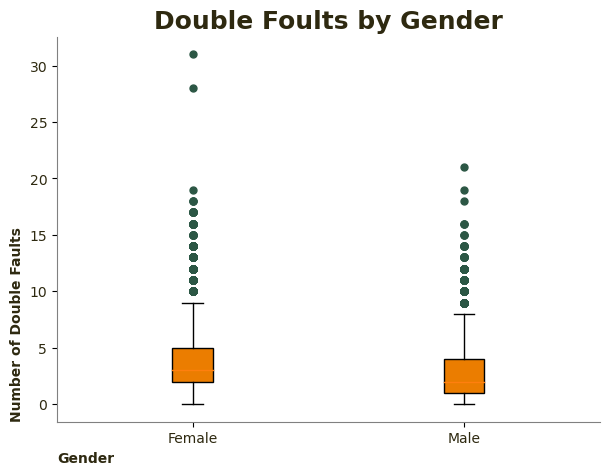

In [109]:
female=double_faults_gender[double_faults_gender["gender"] =="F"]["double_faults"]
male=double_faults_gender[double_faults_gender["gender"]=="M"]["double_faults"]
plt.figure(figsize=(7,5))
bp=plt.boxplot([female,male],labels=["Female","Male"],patch_artist=True,flierprops={"marker":"o","markerfacecolor":"#2C5745","markeredgecolor":"#2C5745","markersize":5})
bp["boxes"][0].set_facecolor("#EB7D00")
bp["boxes"][1].set_facecolor("#EB7D00")

plt.xlabel("Gender",loc="left",color="#2E2910",weight="bold")
plt.ylabel("Number of Double Faults",loc="bottom",color="#2E2910",weight="bold")
plt.title("Double Foults by Gender",weight="bold",color="#2E2910",fontsize=18)
plt.xticks(color="#2E2910")
plt.yticks(color="#2E2910")
ax=plt.gca()
ax.spines[["top","right"]].set_visible(False)
ax.spines[["bottom","left"]].set_color("gray")

plt.show()

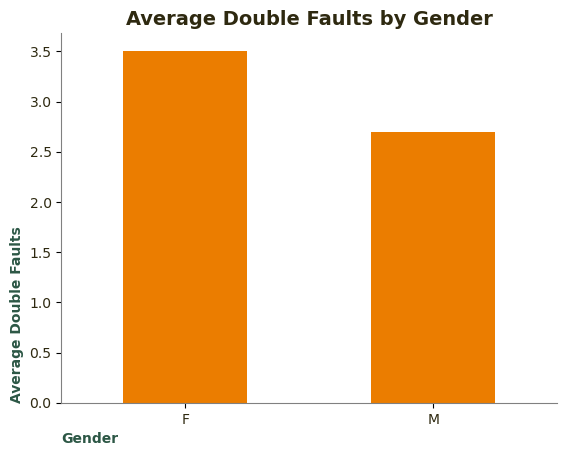

In [118]:
mean_gender=(double_faults_gender.groupby("gender")["double_faults"].mean())
mean_gender.plot(kind="bar",color="#EB7D00")
plt.xlabel("Gender",loc="left",color="#2C5745",weight="bold")
plt.ylabel("Average Double Faults",loc="bottom",color="#2C5745",weight="bold")
plt.title("Average Double Faults by Gender",weight="bold",fontsize=14,color="#2E2910")
plt.xticks(rotation=0,color="#2E2910")
plt.yticks(color="#2E2910")
ax=plt.gca()
ax.spines[["top","right"]].set_visible(False)
ax.spines[["bottom","left"]].set_color("gray")
plt.show()

# Question 9

In [ ]:
final_round= MatchRoundInfo[MatchRoundInfo["name"]=="Final"].copy()
final_round["date"] = pd.to_datetime(final_round["date"])
final_round = (final_round.sort_values(["match_id", "date"]).drop_duplicates("match_id", keep="last").copy())

tournaments = MatchTournamentInfo[["match_id","tournament_id","tournament_name","date"]].copy()
tournaments["date"] = pd.to_datetime(tournaments["date"])
tournaments = (tournaments.sort_values(["match_id", "date"]).drop_duplicates("match_id", keep="last").copy())

events =MatchEventInfo[["match_id","winner_code","start_datetime","date"]].copy()
events["date"] = pd.to_datetime(events["date"])
events = (events.sort_values(["match_id", "date"]).drop_duplicates("match_id", keep="last").copy())

home_player=MatchHomeTeamInfo[["match_id","player_id","full_name","date"]].copy()
home_players["date"] = pd.to_datetime(home_players["date"])
home_player = home_player.sort_values(["match_id","date"]).drop_duplicates("match_id",keep="last").rename(columns={"player_id":"home_player_id","full_name":"home_player"})

away_player=MatchAwayTeamInfo[["match_id","player_id","full_name","date"]].copy()
away_players["date"] = pd.to_datetime(away_players["date"])
away_player = away_player.sort_values(["match_id","date"]).drop_duplicates("match_id",keep="last").rename(columns={"player_id":"away_player_id","full_name":"away_player"})

In [151]:
finals = (final_round[["match_id"]]
          .merge(events,on="match_id",how="left")
          .merge(tournaments[["match_id","tournament_id","tournament_name"]],on="match_id",how="left")
          .merge(home_player[["match_id","home_player_id","home_player"]],on="match_id",how="left")
          .merge(away_player[["match_id","away_player_id","away_player"]],on="match_id",how="left")
          )
finals.head()

,match_id,winner_code,start_datetime,date,tournament_id,tournament_name,home_player_id,home_player,away_player_id,away_player
0,11998455,2.0,1707055200,2024-02-05,126168,"Montpellier, France",64580.0,"Ćorić, Borna",163480.0,"Bublik, Alexander"
1,11998663,1.0,1707012000,2024-02-04,126174,"Burnie 1, Australia",79467.0,"Jasika, Omar",58369.0,"Bolt, Alex"
2,11998773,1.0,1707069600,2024-02-05,126179,"Cleveland, USA",210490.0,"Kypson, Patrick",334293.0,"Quinn, Ethan"
3,11999016,1.0,1707051600,2024-02-05,126192,"Koblenz, Germany",200159.0,"Rodionov, Jurij",235576.0,"Nakashima, Brandon"
4,11999218,2.0,1707055200,2024-02-05,126196,"Piracicaba, Brazil",54573.0,"Coria, Federico",196122.0,"Ugo Carabelli, Camilo"


In [153]:
finals["winner_id"] = np.where(finals["winner_code"] == 1,finals["home_player_id"], np.where(finals["winner_code"]==2,finals["away_player_id"],np.nan))
finals["winner"] = np.where(finals["winner_code"] == 1,finals["home_player"], np.where(finals["winner_code"]==2,finals["away_player"],np.nan))


In [155]:
finals["match_date"]=pd.to_datetime(finals["start_datetime"],unit="s")
finals["month"]=finals["match_date"].dt.to_period("M")
titles=finals.dropna(subset=["winner_id","month","tournament_id"]).copy()
monthly_titles=(titles.groupby(["winner_id","winner","month"])["tournament_id"].nunique().reset_index(name="tournament_won"))

In [156]:
result = monthly_titles.sort_values("tournament_won",ascending=False)
result.head(20)

,winner_id,winner,month,tournament_won
188,341818.0,"Faria, Jaime",2024-03,3
196,372311.0,"Nicod, Jakub",2024-03,3
135,230049.0,"Jianu, Filip Cristian",2024-03,3
76,152766.0,"Helgo, Malene",2024-03,3
14,50901.0,"Popko, Dmitry",2024-02,3
107,202572.0,"Gengel, Marek",2024-02,3
58,111857.0,"Ursu, Vadym",2024-03,2
201,381430.0,"Valentova, Tereza",2024-02,2
28,63642.0,"Kwiatkowski, Thai-Son",2024-03,2
163,289173.0,"Hussey, Giles",2024-03,2


Faria, Jaime won the most tournaments in a single month, winning 3 tournaments in March 2024. And the Popko, Dmitry won the most tournaments in a single month, winning 3 tournaments in February 2024

In [ ]:
top10 = result.head(10).copy()
top10["label"] = (top10["winner"].astype(str) + " (" + top10["month"].astype(str) + ")")

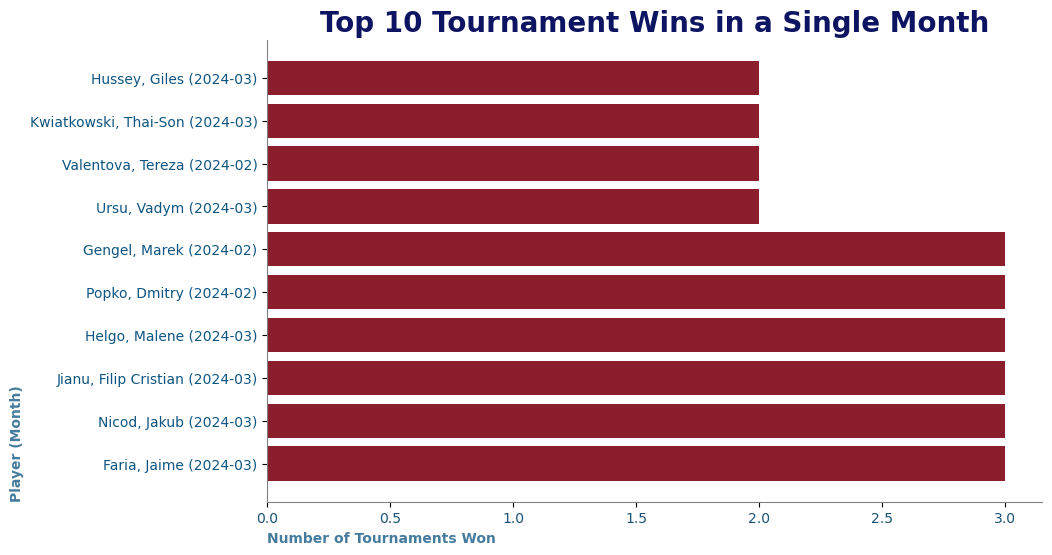

In [175]:
plt.figure(figsize=(10, 6))

plt.barh(
    top10["label"],
    top10["tournament_won"],color="#8B1E2D"
)

plt.xlabel("Number of Tournaments Won",loc="left",color="#457B9D",weight="bold")
plt.ylabel("Player (Month)",loc="bottom",color="#457B9D",weight="bold")
plt.title("Top 10 Tournament Wins in a Single Month",color="#0D1461",fontsize=20,weight="bold")
plt.xticks(color="#1A5275")
plt.yticks(color="#0E5581")
ax=plt.gca()
ax.spines[["top","right"]].set_visible(False)
ax.spines[["bottom","left"]].set_color("gray")

plt.show()

# Question 10

In [4]:
h_players = MatchHomeTeamInfo[["player_id", "full_name", "height", "current_rank", "date"]].copy()
a_players = MatchAwayTeamInfo[["player_id", "full_name", "height", "current_rank", "date"]].copy()
players=pd.concat([h_players,a_players],ignore_index=True)
print("Row:",len(players))
print("unique players:",players["player_id"].nunique())

Row: 49813
unique players: 2644


we will probably have many more rows than unique players because players participate in multiple matches.

In [5]:
players["height"] = pd.to_numeric(players["height"],errors="coerce")
players["current_rank"] = pd.to_numeric(players["current_rank"],errors="coerce")
players["date"] = pd.to_datetime(players["date"])

In [6]:
players[["height","current_rank"]].isna().sum()

height          21952
current_rank      598
dtype: int64

This is important because players without height or ranking cannot be included in the correlation calculation.

In [ ]:
# Latest available height for each player
player_height = (
    players
    .dropna(subset=["height"])
    .sort_values(["player_id", "date"])
    .drop_duplicates("player_id", keep="last")
    [["player_id", "height"]]
)
# Latest available ranking for each player
player_rank = (
    players
    .dropna(subset=["current_rank"])
    .sort_values(["player_id", "date"])
    .drop_duplicates("player_id", keep="last")
    [["player_id", "current_rank"]]
)
players_corr = player_height.merge(
    player_rank,
    on="player_id",
    how="inner"
)
print("Rows:", len(players_corr))
print("Unique players:", players_corr["player_id"].nunique())

Rows: 1340
Unique players: 1340


In [14]:
players_corr

,player_id,height,current_rank
0,14414,1.83,122.0
1,14486,1.85,652.0
2,14548,1.83,70.0
3,14844,1.93,45.0
4,14882,1.88,1.0
...,...,...,...
1335,463772,1.93,1219.0
1336,464370,1.80,1159.0
1337,483188,1.88,897.0
1338,487577,1.78,1284.0


In [10]:
players_corr[["height", "current_rank"]].describe()

,height,current_rank
count,1340.000000,1340.000000
mean,1.822052,580.473134
std,0.080997,446.975387
min,1.570000,1.000000
25%,1.780000,193.750000
50%,1.830000,474.500000
75%,1.880000,899.000000
max,2.080000,1858.000000


In [12]:
correlation = players_corr["height"].corr(players_corr["current_rank"])
print("Correlation:", correlation)

Correlation: 0.10478103579162656


The Pearson correlation between player height and current ranking was approximately 0.105, indicating a very weak positive relationship. This suggests that player height has little linear association with ranking in this dataset.

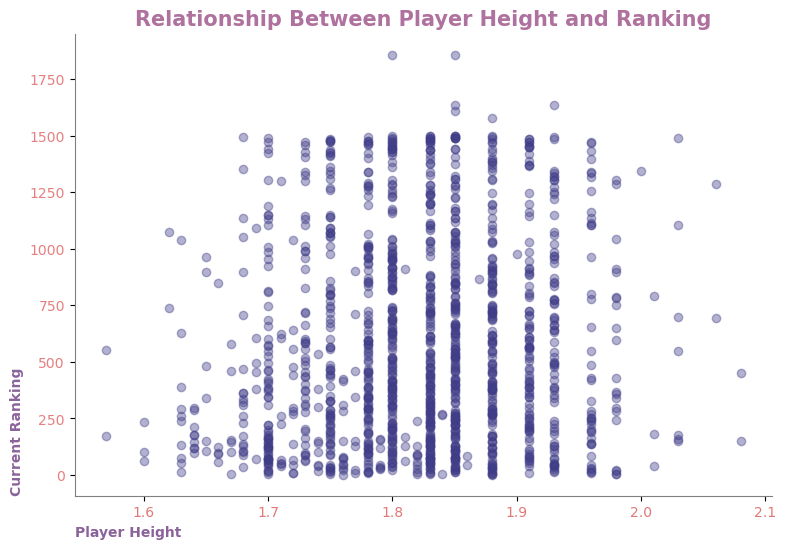

In [17]:
plt.figure(figsize=(9, 6))

plt.scatter(
    players_corr["height"],
    players_corr["current_rank"],
    alpha=0.4,
    color="#403D88"
)

plt.xlabel("Player Height",weight="bold",loc="left",color="#8B639B")
plt.ylabel("Current Ranking",weight="bold",loc="bottom",color="#8B639B")
plt.title("Relationship Between Player Height and Ranking",fontsize=15,color="#AF719D",weight="bold")
plt.xticks(color="#E27777")
plt.yticks(color="#E67F7F")
ax=plt.gca()
ax.spines[["top","right"]].set_visible(False)
ax.spines[["bottom","left"]].set_color("gray")

plt.show()

# Question 11

In [11]:
MatchTimeInfo[["period_1","period_2","period_3","period_4","period_5"]].describe()

,period_1,period_2,period_3
count,22576.000000,22471.000000,6886.000000
mean,2968.423990,3191.026568,3292.027157
std,6250.475337,6107.149799,6826.886790
min,2.000000,-16200.000000,0.000000
25%,2047.000000,2120.500000,1961.000000
50%,2521.000000,2610.000000,2608.000000
75%,3157.000000,3259.500000,3308.000000
max,172606.000000,169438.000000,152072.000000


A negative set duration is impossible.(172606 seconds ≈ 47.9 hours) for one set is clearly not a valid tennis set duration.

In [12]:
print("Rows:", len(MatchTimeInfo))
print("Unique matches:", MatchTimeInfo["match_id"].nunique())
print("Exact duplicate rows:", MatchTimeInfo.duplicated().sum())

Rows: 35671
Unique matches: 16873
Exact duplicate rows: 0


In [13]:
MatchTimeInfo["date"] = pd.to_datetime(MatchTimeInfo["date"])
time_final = (MatchTimeInfo.sort_values(["match_id","date"]).drop_duplicates("match_id",keep="last").copy())
period_cols = ["period_1","period_2","period_3","period_4","period_5"]
for col in period_cols:
    MatchTimeInfo[col] = pd.to_numeric(MatchTimeInfo[col],errors="coerce")
MatchTimeInfo[period_cols].stack().describe(percentiles=[0.90,0.95,0.99,0.995,0.999])

count     51933.000000
mean       3107.650184
std        6270.238413
min      -16200.000000
50%        2568.000000
90%        3941.000000
95%        4425.000000
99%        6498.000000
99.5%     19830.300000
99.9%     86430.000000
max      172606.000000
dtype: float64

In [14]:
invalid_period=((time_final[period_cols]<0)|(time_final[period_cols]>21600)).any(axis=1)
print("Matches with clearly invalid period values:",invalid_period.sum())

Matches with clearly invalid period values: 88


21600 seconds = 6 hours _ This is intentionally generous. We are not saying a set officially has a six-hour maximum. We are using it to separate obvious data errors such as 20–48 hour set durations from legitimate long matches.

In [15]:
time_clean = time_final[~invalid_period].copy()
time_clean["duration_seconds"] = (time_clean[period_cols].sum(axis=1, min_count=1))
time_clean["duration_minutes"] = (time_clean["duration_seconds"] / 60)
time_clean["duration_minutes"].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999])

count     11001.0
unique     5790.0
top          79.7
freq          9.0
Name: duration_minutes, dtype: float64

In [16]:
duration_final = time_clean[(time_clean["duration_minutes"] >= 10) &(time_clean["duration_minutes"] <= 360)].copy()
print("Before:", time_clean["duration_minutes"].notna().sum())
print("After:", len(duration_final))

Before: 11001
After: 10979


In [17]:
duration_final["duration_minutes"].describe(
    percentiles=[0.90, 0.95, 0.99]
)

count     10979.0
unique     5770.0
top          79.7
freq          9.0
Name: duration_minutes, dtype: float64

In [18]:
average_duration = duration_final["duration_minutes"].mean()
print(f"Average match duration: {average_duration:.2f} minutes")
hours = int(average_duration // 60)
minutes = int(round(average_duration % 60))
print(f"Average match duration: "f"{hours} hour(s) and {minutes} minutes")

Average match duration: 103.68 minutes
Average match duration: 1 hour(s) and 44 minutes


The average match duration was approximately 103.68 minutes (about 1 hour and 44 minutes) among matches with available and usable duration data.After excluding clearly invalid duration records and matches with missing duration information, 10,979 matches were included in the analysis.

# Question 12

In [64]:
home_score = MatchHomeScoreInfo[["match_id", "date"] + period_cols].copy()
away_score = MatchAwayScoreInfo[["match_id", "date"] + period_cols].copy()
home_score = home_score.rename(columns={col: f"home_{col}" for col in period_cols})
away_score = away_score.rename(columns={col: f"away_{col}"for col in period_cols})
scores=home_score.merge(away_score,on=["match_id","date"],how="inner")
scores["date"]=pd.to_datetime(scores["date"])

In [65]:
scores_final = (scores.sort_values(["match_id", "date"]).drop_duplicates(subset="match_id",keep="last").copy())

print("Rows:", len(scores_final))
print("Unique matches:",scores_final["match_id"].nunique())

Rows: 16873
Unique matches: 16873


In [ ]:
home_gender = (MatchHomeTeamInfo[["match_id", "gender"]].dropna(subset=["gender"]).drop_duplicates().groupby("match_id", as_index=False)["gender"].first().rename(columns={"gender": "gender_home"}))
away_gender = (MatchAwayTeamInfo[["match_id", "gender"]].dropna(subset=["gender"]).drop_duplicates().groupby("match_id", as_index=False)["gender"].first().rename(columns={"gender": "gender_away"}))
gender_check = home_gender.merge(away_gender,on="match_id",how="outer")

In [68]:
for col in period_cols:
    scores_final[f"home_{col}"] = pd.to_numeric(scores_final[f"home_{col}"],errors="coerce")
    scores_final[f"away_{col}"] = pd.to_numeric(scores_final[f"away_{col}"],errors="coerce")

gender_check["gender"]=(gender_check["gender_home"].fillna(gender_check["gender_away"]))
match_gender=(gender_check[["match_id","gender"]].drop_duplicates("match_id"))
scores_final =scores_final.drop(columns=["gender"],errors="ignore")
scores_final = scores_final.merge(match_gender,on="match_id",how="left")
scores_final["gender"].value_counts(dropna=False)

gender
M      8228
F      5958
NaN    2687
Name: count, dtype: int64

After combining the gender information from the home and away player datasets and merging it with the match score data, **2,687 matches** still had missing gender values.

These missing values occur because no valid gender information was available for those `match_id`s in either the home-team or away-team data.

The score dataset contains **16,873 unique matches**, of which:

- **8,228 matches** were identified as men's matches (`M`)
- **5,958 matches** were identified as women's matches (`F`)
- **2,687 matches** had no available gender information

Because the missing gender values cannot be reliably inferred, these matches were excluded only from the gender-based comparison. The analysis of average games per set by gender was therefore performed using matches with known gender information only.

In [90]:
scores_gender = scores_final.dropna(subset=["gender"]).copy()
for col in period_cols:
    scores_final[f"games_{col}"] = (scores_final[f"home_{col}"] +scores_final[f"away_{col}"])

game_cols = [f"games_{col}"for col in period_cols]

sets = scores_final[["match_id", "gender"] + game_cols].melt(id_vars=["match_id", "gender"],value_vars=game_cols,var_name="set",value_name="games")  

sets_clean = sets.dropna(subset=["gender", "games"]).copy()
sets_clean = sets_clean[sets_clean["games"] > 0].copy()
sets_clean.sort_values("games",ascending=False).head(10)

,match_id,gender,set,games
35032,12041957,M,games_period_3,40.0
38180,12078777,M,games_period_3,32.0
41799,12121259,F,games_period_3,31.0
35125,12042582,M,games_period_3,30.0
42280,12123966,M,games_period_3,30.0
42090,12122156,M,games_period_3,29.0
41609,12120611,F,games_period_3,29.0
48933,12190437,M,games_period_3,28.0
34977,12041793,M,games_period_3,28.0
42155,12123672,F,games_period_3,27.0


In [78]:
result = (sets_clean.groupby("gender")["games"].agg(["count", "mean", "median", "std"]))
result

,count,mean,median,std
gender,,,,
F,13112,9.213850,9.0,2.482405
M,18041,9.594368,9.0,2.535224


Men's matches averaged 9.59 games per set, compared with 9.21 games per set in women's matches. Therefore, sets in men's matches were slightly longer in terms of games in this dataset.

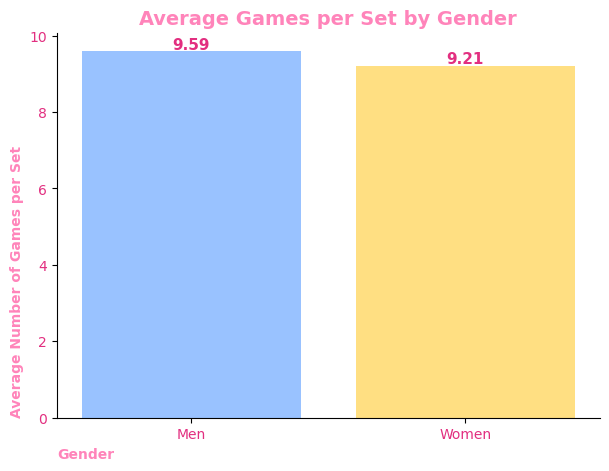

In [92]:

mean_games = result["mean"].reindex(["M", "F"])

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Men", "Women"],
    mean_games.values,
    color=["#99C2FF", "#FFDF82"]
)

plt.xlabel("Gender",loc="left",weight="bold",color="#FF84BA")
plt.ylabel("Average Number of Games per Set",loc="bottom",weight="bold",color="#FF84BA")
plt.title(
    "Average Games per Set by Gender",
    fontsize=14,
    weight="bold",color="#FF84BA"
)
plt.xticks(color="#E22F80")
plt.yticks(color="#E22F80")

# Show the mean above each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{bar.get_height():.2f}",
        ha="center",
        fontsize=11,
        weight="bold",color="#E22F80"
    )

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

# Question 13 

To determine the distribution of left-handed and right-handed players, the home and away player datasets were combined. Duplicate players were removed using player_id to ensure that each player was counted only once. The plays column was then used to classify players as left-handed or right-handed.

In [4]:
players = pd.concat([
    MatchHomeTeamInfo[["player_id", "plays"]],
    MatchAwayTeamInfo[["player_id", "plays"]]
])
players = players.drop_duplicates(subset="player_id")
print("Number of players:", len(players))
print("Unique player IDs:", players["player_id"].nunique())

print("\nPlays:")
print(players["plays"].value_counts(dropna=False))


Number of players: 2644
Unique player IDs: 2644

Plays:
plays
None            1498
right-handed    1013
left-handed      133
Name: count, dtype: int64


In [5]:
players["plays"].value_counts()

plays
right-handed    1013
left-handed      133
Name: count, dtype: int64

In [6]:
print("Percentage")
players["plays"].value_counts(normalize=True) * 100

Percentage


plays
right-handed    88.394415
left-handed     11.605585
Name: proportion, dtype: float64

**Interpretation** 

 The results show that right-handed players are considerably more common in the dataset. Approximately 88.4% of the players are right-handed, compared with only 11.6% who are left-handed.

Handedness information was missing for 1,498 out of 2,644 players (56.7%), so the percentages were calculated only for players with available data.

# Question 14

To identify the most common surface type, the ground_type column from the tournament information dataset was used. Since each tournament can contain multiple matches, duplicate tournament records were removed based on tournament_id so that each tournament was counted only once.

In [7]:
tournaments = MatchTournamentInfo[
    ["tournament_id", "ground_type"]
].drop_duplicates()

surface_distribution = tournaments["ground_type"].value_counts()

print(surface_distribution)

ground_type
Hardcourt outdoor    239
Red clay             187
Hardcourt indoor      85
Red clay indoor        8
Grass                  8
Carpet indoor          5
Synthetic outdoor      4
Green clay             1
Name: count, dtype: int64


In [8]:
print("Most common surface:", surface_distribution.idxmax())

Most common surface: Hardcourt outdoor


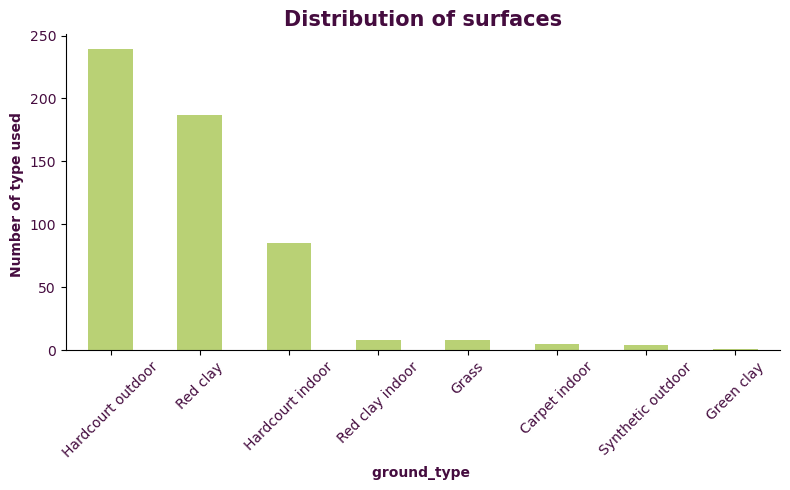

In [25]:
surface_distribution.plot(kind='bar', x='ground_type', y='count', legend=False, figsize=(8,5),color="#B9D175")
plt.ylabel('Number of type used ',weight="bold",color="#450C3F")
plt.xlabel("ground_type ",weight="bold",color="#450C3F")
plt.title('Distribution of surfaces',weight="bold",color="#450C3F",fontsize=15)
plt.xticks(rotation=45, color="#450C3F")
plt.yticks(color="#450C3F")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# Question 15

In [21]:
print(MatchHomeTeamInfo["country"].head())
print(MatchAwayTeamInfo["country"].head())

0     France
1     France
2    Croatia
3        USA
4     France
Name: country, dtype: object
0    Canada
1     Italy
2     Spain
3    France
4    France
Name: country, dtype: object


In [22]:
print(
    "Home players - distinct countries:",
    MatchHomeTeamInfo["country"].nunique()
)

print(
    "Away players - distinct countries:",
    MatchAwayTeamInfo["country"].nunique()
)

Home players - distinct countries: 99
Away players - distinct countries: 96


In [23]:
countries = pd.concat([
    MatchHomeTeamInfo["country"],
    MatchAwayTeamInfo["country"]
])

distinct_countries = countries.dropna().nunique()

print("Number of distinct countries:", distinct_countries)

Number of distinct countries: 101


##### Question 21:  Which countries have the largest number of player records in the dataset?

In [24]:
country_counts = (
    countries
    .dropna()
    .value_counts()
    .head(10)
)

print(country_counts)

country
France            4270
Italy             4057
USA               3644
Russia            2557
Germany           2297
Argentina         2275
Spain             2145
Japan             2132
Australia         1714
United Kingdom    1553
Name: count, dtype: int64


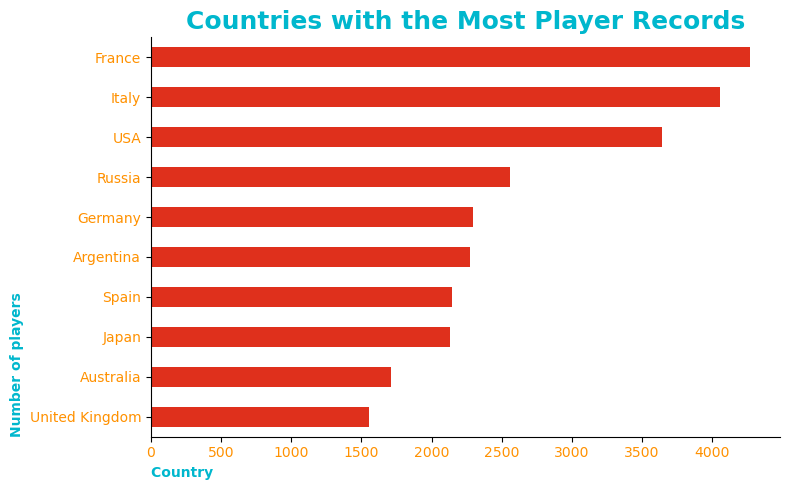

In [39]:
country_counts.plot(kind='barh', x='Country', y='Number of players', legend=False, figsize=(8,5),color="#DF301C")
plt.ylabel('Number of players ',weight="bold",color="#00B7CD",loc="bottom")
plt.xlabel("Country ",weight="bold",color="#00B7CD",loc="left")
plt.title("Countries with the Most Player Records",weight="bold",color="#00B7CD",fontsize=18)
plt.xticks(color="#FF9100")
plt.yticks(color="#FF9100")
ax = plt.gca()
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# Question 16

In [ ]:
print("Home rank sample:")
print(
    MatchHomeTeamInfo[
        ["match_id", "player_id", "full_name", "current_rank","date"]
    ].head(10)
)

print("\nAway rank sample:")
print(
    MatchAwayTeamInfo[
        ["match_id", "player_id", "full_name", "current_rank","date"]
    ].head(10)
)

print("\nWinner codes:")
print(
    MatchEventInfo[["match_id","winner"]]
    .value_counts(dropna=False)
    .sort_index()
)

Home rank sample:
   match_id  player_id              full_name  current_rank      date
0  11998445     287803         Cazaux, Arthur          86.0  20240201
1  11998446      62790    Lestienne, Constant          99.0  20240201
2  11998447      64580           Ćorić, Borna          31.0  20240201
3  11998448     131442          Mmoh, Michael         122.0  20240201
4  11998449      22218          Paire, Benoit         110.0  20240201
5  11998450     117916      Shapovalov, Denis         120.0  20240201
6  11998451     264344  Shevchenko, Alexander          47.0  20240201
7  11998456     264344  Shevchenko, Alexander          47.0  20240201
8  11998459     283070           Rune, Holger           7.0  20240201
9  11998666      39712          Saville, Luke         295.0  20240201

Away rank sample:
   match_id  player_id               full_name  current_rank      date
0  11998445     192013  Auger-Aliassime, Felix          30.0  20240201
1  11998446     273680          Flavio Cobolli     

Concern: Before calculating the winning percentage, I needed to make sure that each match was counted only once. Therefore, I first checked whether match_id was unique in the three datasets used for the analysis.

In [41]:
check = MatchEventInfo[
    ["match_id", "winner_code"]
].merge(
    MatchHomeTeamInfo[
        ["match_id", "full_name", "current_rank"]
    ],
    on="match_id"
).merge(
    MatchAwayTeamInfo[
        ["match_id", "full_name", "current_rank"]
    ],
    on="match_id",
    suffixes=("_home", "_away")
)

print(check.head(10).to_string(index=False))

 match_id  winner_code      full_name_home  current_rank_home         full_name_away  current_rank_away
 11998445          2.0      Cazaux, Arthur               86.0 Auger-Aliassime, Felix               30.0
 11998445          2.0      Cazaux, Arthur               86.0 Auger-Aliassime, Felix               30.0
 11998445          2.0      Cazaux, Arthur               86.0 Auger-Aliassime, Felix               30.0
 11998445          2.0      Cazaux, Arthur               86.0 Auger-Aliassime, Felix               30.0
 11998445          2.0      Cazaux, Arthur               86.0 Auger-Aliassime, Felix               30.0
 11998445          2.0      Cazaux, Arthur               86.0 Auger-Aliassime, Felix               30.0
 11998445          2.0      Cazaux, Arthur               86.0 Auger-Aliassime, Felix               30.0
 11998445          2.0      Cazaux, Arthur               86.0 Auger-Aliassime, Felix               30.0
 11998446          2.0 Lestienne, Constant               99.0   

The results showed that match_id was not unique in any of the three datasets. Therefore, I needed to investigate the reason for these duplicate records before removing them.

Concern: I needed to determine whether the duplicated match_id values represented different matches or repeated records of the same match. Removing duplicates without checking this could lead to loss of important information.

In [42]:
print(
    MatchEventInfo[
        MatchEventInfo["match_id"] == 11998445
    ].to_string(index=False)
)

print(
    MatchHomeTeamInfo[
        MatchHomeTeamInfo["match_id"] == 11998445
    ].to_string(index=False)
)

print(
    MatchAwayTeamInfo[
        MatchAwayTeamInfo["match_id"] == 11998445
    ].to_string(index=False)
)

 match_id  first_to_serve home_team_seed away_team_seed custom_id  winner_code  default_period_count  start_datetime             match_slug  final_result_only     date
 11998445             1.0           None              3 nPBbsdgpc          2.0                     3      1706810400 cazaux-auger-aliassime              False 20240201
 11998445             1.0           None              3 nPBbsdgpc          2.0                     3      1706810400 cazaux-auger-aliassime              False 20240202
 match_id      name          slug gender  user_count residence          birthplace  height  weight        plays turned_pro  current_prize  total_prize  player_id  current_rank name_code country      full_name     date
 11998445 Cazaux A. cazaux-arthur      M        4481      None Montpellier, France    1.83     NaN right-handed       None       233290.0     643582.0     287803          86.0       CAZ  France Cazaux, Arthur 20240201
 11998445 Cazaux A. cazaux-arthur      M        4481      No

The investigation showed that the same match was recorded on different dates, while the players, rankings, match result, and other match information remained unchanged. Therefore, these records represented repeated observations of the same match rather than different matches.

Concern: Since the duplicated records represented the same match, I needed to keep only one record for each match_id to ensure that every match was counted once in the analysis.

In [43]:
MatchEventInfo_unique = MatchEventInfo.drop_duplicates(
    subset="match_id"
)

MatchHomeTeamInfo_unique = MatchHomeTeamInfo.drop_duplicates(
    subset="match_id"
)

MatchAwayTeamInfo_unique = MatchAwayTeamInfo.drop_duplicates(
    subset="match_id"
)

After removing duplicate records based on match_id, each match was represented only once in the datasets. This prevents repeated matches from affecting the calculation of winning percentages.

Concern: To calculate each player's winning percentage, I needed to determine which player won each match. Therefore, I examined the winner_code variable.

In [44]:
print(
    MatchEventInfo["winner_code"]
    .value_counts(dropna=False)
    .sort_index()
)

winner_code
1.0    16552
2.0    15452
NaN     3049
Name: count, dtype: int64


The winner_code variable contains two main values. A value of 1 indicates that the home player won, while a value of 2 indicates that the away player won. Missing values were also present in the dataset.

Concern: After removing duplicate records, I needed to combine the home-player, away-player, and match-result information into a single dataset. This allows each match to contain the identities and rankings of both players, as well as the winner.

In [45]:
matches = (
    MatchEventInfo_unique[
        ["match_id", "winner_code"]
    ]
    .merge(
        MatchHomeTeamInfo_unique[
            ["match_id", "player_id", "full_name", "current_rank"]
        ],
        on="match_id",
        how="inner"
    )
    .merge(
        MatchAwayTeamInfo_unique[
            ["match_id", "player_id", "full_name", "current_rank"]
        ],
        on="match_id",
        how="inner",
        suffixes=("_home", "_away")
    )
)

print("Shape:", matches.shape)
print(matches.head())

Shape: (9882, 8)
   match_id  winner_code  player_id_home       full_name_home  \
0  11998445          2.0          287803       Cazaux, Arthur   
1  11998446          2.0           62790  Lestienne, Constant   
2  11998447          1.0           64580         Ćorić, Borna   
3  11998448          1.0          131442        Mmoh, Michael   
4  11998449          2.0           22218        Paire, Benoit   

   current_rank_home  player_id_away          full_name_away  \
0               86.0          192013  Auger-Aliassime, Felix   
1               99.0          273680          Flavio Cobolli   
2               31.0           77223         Martinez, Pedro   
3              122.0           88992       Muller, Alexandre   
4              110.0          248846           Mayot, Harold   

   current_rank_away  
0               30.0  
1               69.0  
2              101.0  
3               81.0  
4              132.0  


Concern: I needed to combine the match result with the information of both players so that each match could be analyzed based on the players' identities and rankings.

In [46]:
matches = (
    MatchEventInfo_unique[
        ["match_id", "winner_code"]
    ]
    .merge(
        MatchHomeTeamInfo_unique[
            ["match_id", "player_id", "full_name", "current_rank"]
        ],
        on="match_id",
        how="inner"
    )
    .merge(
        MatchAwayTeamInfo_unique[
            ["match_id", "player_id", "full_name", "current_rank"]
        ],
        on="match_id",
        how="inner",
        suffixes=("_home", "_away")
    )
)

The three datasets were successfully merged into a single match-level dataset containing 9,882 matches. Each record includes the home and away players, their current rankings, and the match winner.

Concern: The question specifically asks about winning performance against Top 10 opponents. Therefore, I needed to identify matches in which at least one of the two players was ranked within the Top 10.

In [47]:
top10_matches = matches[
    (matches["current_rank_home"] <= 10) |
    (matches["current_rank_away"] <= 10)
].copy()

print("Total matches:", len(matches))
print("Matches involving a Top 10 player:", len(top10_matches))

print(top10_matches[
    [
        "match_id",
        "full_name_home",
        "current_rank_home",
        "full_name_away",
        "current_rank_away",
        "winner_code"
    ]
].head(10))

Total matches: 9882
Matches involving a Top 10 player: 222
     match_id          full_name_home  current_rank_home      full_name_away  \
8    11998459            Rune, Holger                7.0  Llamas Ruiz, Pablo   
53   12002055       Ostapenko, Jelena               10.0       Tauson, Clara   
154  12021512  Bielinskyi, Viacheslav              499.0       Fritz, Taylor   
224  12024041           Fomin, Sergey              656.0     Hurkacz, Hubert   
265  11998454            Rune, Holger                7.0       Mmoh, Michael   
280  12002059       Ostapenko, Jelena               10.0      Burrage, Jodie   
285  12021514        Krutykh, Oleksii              392.0       Fritz, Taylor   
293  12024039      Sultanov, Khumoyun              332.0     Hurkacz, Hubert   
394  12028119        Orlov, Vladyslav              606.0       Fritz, Taylor   
407  11998457            Rune, Holger                7.0        Ćorić, Borna   

     current_rank_away  winner_code  
8                151.0

Concern: Identifying matches involving a Top 10 player is not enough. I needed to determine which player was actually facing the Top 10 opponent in each match. Therefore, the data was transformed from a match-based structure into a player-versus-opponent structure.

In [48]:
top10_opponent_matches = []

for _, row in matches.iterrows():

    # Home player faced a Top 10 opponent
    if row["current_rank_away"] <= 10:
        top10_opponent_matches.append({
            "match_id": row["match_id"],
            "player_id": row["player_id_home"],
            "player": row["full_name_home"],
            "opponent_id": row["player_id_away"],
            "opponent": row["full_name_away"],
            "opponent_rank": row["current_rank_away"],
            "winner_code": row["winner_code"],
            "player_side": "home"
        })

    # Away player faced a Top 10 opponent
    if row["current_rank_home"] <= 10:
        top10_opponent_matches.append({
            "match_id": row["match_id"],
            "player_id": row["player_id_away"],
            "player": row["full_name_away"],
            "opponent_id": row["player_id_home"],
            "opponent": row["full_name_home"],
            "opponent_rank": row["current_rank_home"],
            "winner_code": row["winner_code"],
            "player_side": "away"
        })

top10_opponent_matches = pd.DataFrame(top10_opponent_matches)

print("Shape:", top10_opponent_matches.shape)
print(top10_opponent_matches.head(10))

Shape: (237, 8)
   match_id  player_id                  player  opponent_id  \
0  11998459     264358      Llamas Ruiz, Pablo       283070   
1  12002055     252168           Tauson, Clara        64496   
2  12021512     339443  Bielinskyi, Viacheslav       136042   
3  12024041     198223           Fomin, Sergey       158896   
4  11998454     131442           Mmoh, Michael       283070   
5  12002059     172590          Burrage, Jodie        64496   
6  12021514     232615        Krutykh, Oleksii       136042   
7  12024039     149100      Sultanov, Khumoyun       158896   
8  12028119     154570        Orlov, Vladyslav       136042   
9  11998457      64580            Ćorić, Borna       283070   

            opponent  opponent_rank  winner_code player_side  
0       Rune, Holger            7.0          1.0        away  
1  Ostapenko, Jelena           10.0          1.0        away  
2      Fritz, Taylor           10.0          NaN        home  
3    Hurkacz, Hubert            8.0   

Concern: After identifying each player's matches against Top 10 opponents, I needed to determine whether the player won or lost each match. Since winner_code identifies the winning side rather than the winning player directly, the player's side (home or away) was used to determine the result.

In [49]:
def get_result(row):
    if pd.isna(row["winner_code"]):
        return "Unknown"
    
    if row["player_side"] == "home" and row["winner_code"] == 1:
        return "Win"
    
    if row["player_side"] == "away" and row["winner_code"] == 2:
        return "Win"
    
    return "Loss"


top10_opponent_matches["result"] = (
    top10_opponent_matches.apply(get_result, axis=1)
)

print(
    top10_opponent_matches[
        ["player", "opponent", "opponent_rank",
         "player_side", "winner_code", "result"]
    ].head(15)
)

                       player           opponent  opponent_rank player_side  \
0          Llamas Ruiz, Pablo       Rune, Holger            7.0        away   
1               Tauson, Clara  Ostapenko, Jelena           10.0        away   
2      Bielinskyi, Viacheslav      Fritz, Taylor           10.0        home   
3               Fomin, Sergey    Hurkacz, Hubert            8.0        home   
4               Mmoh, Michael       Rune, Holger            7.0        away   
5              Burrage, Jodie  Ostapenko, Jelena           10.0        away   
6            Krutykh, Oleksii      Fritz, Taylor           10.0        home   
7          Sultanov, Khumoyun    Hurkacz, Hubert            8.0        home   
8            Orlov, Vladyslav      Fritz, Taylor           10.0        home   
9                Ćorić, Borna       Rune, Holger            7.0        away   
10  Pavlyuchenkova, Anastasia  Ostapenko, Jelena            9.0        away   
11     Alexandrova, Ekaterina  Ostapenko, Jelena    

In [50]:
print("\nResult distribution:")
print(
    top10_opponent_matches["result"]
    .value_counts(dropna=False)
)


Result distribution:
result
Loss       160
Win         66
Unknown     11
Name: count, dtype: int64


Concern: I needed to calculate the winning percentage of each player against Top 10 opponents. Since 11 matches had missing winner information, these observations were excluded from the calculation rather than being treated as wins or losses.

In [51]:
top10_known = top10_opponent_matches[
    top10_opponent_matches["result"].isin(["Win", "Loss"])
].copy()
player_performance = (
    top10_known
    .groupby("player")
    .agg(
        top10_matches=("result", "count"),
        wins=("result", lambda x: (x == "Win").sum())
    )
    .reset_index()
)
player_performance["winning_percentage"] = (
    player_performance["wins"]
    / player_performance["top10_matches"]
    * 100
)

In [56]:
player_performance = player_performance.sort_values(
    "winning_percentage",
    ascending=False
)

print(player_performance.head(20))

                   player  top10_matches  wins  winning_percentage
130          Ćorić, Borna              1     1               100.0
36   Haddad Maia, Beatriz              1     1               100.0
2        Altmaier, Daniel              1     1               100.0
120       Volynets, Katie              1     1               100.0
119          Vekić, Donna              1     1               100.0
5        Avanesyan, Elina              1     1               100.0
114       Tsurenko, Lesia              1     1               100.0
111      Thompson, Jordan              1     1               100.0
109          Swiatek, Iga              3     3               100.0
81       Paolini, Jasmine              1     1               100.0
73            Nardi, Luca              1     1               100.0
70       Monteiro, Thiago              1     1               100.0
12      Bublik, Alexander              1     1               100.0
66        Michelsen, Alex              1     1               1

Concern: The initial results showed that several players had a 100% winning percentage against Top 10 opponents, but many of them had played only one match. A winning percentage based on a single match may not provide a reliable comparison. Therefore, I introduced a minimum-match threshold and considered only players who had faced Top 10 opponents at least five times.

In [53]:
qualified_players = player_performance[
    player_performance["top10_matches"] >= 5
].copy()

qualified_players = qualified_players.sort_values(
    "winning_percentage",
    ascending=False
)

print(qualified_players.head(10))

                player  top10_matches  wins  winning_percentage
22    Dimitrov, Grigor              6     3                50.0
6   Azarenka, Victoria              5     2                40.0


Grigor Dimitrov had the highest winning percentage against Top 10 opponents among players with at least five recorded matches, winning 50% of his matches (3 out of 6).

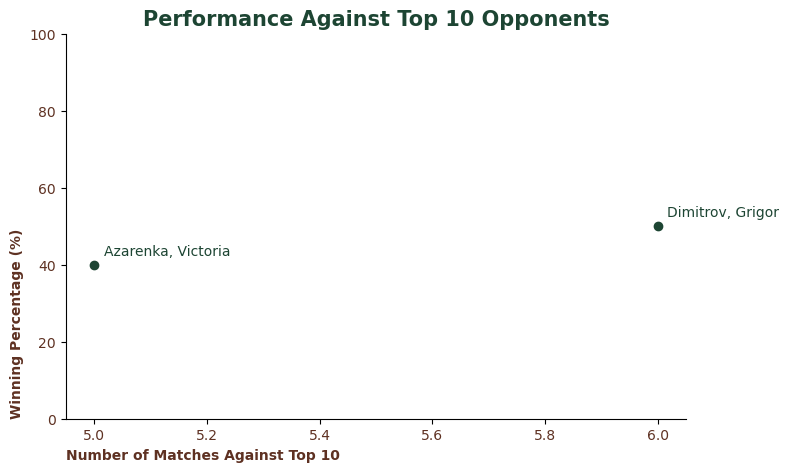

In [62]:
plt.figure(figsize=(8, 5))

plt.scatter(
    qualified_players["top10_matches"],
    qualified_players["winning_percentage"],color="#1D4533"
)

for _, row in qualified_players.iterrows():
    plt.annotate(
        row["player"],
        (row["top10_matches"], row["winning_percentage"]),
        xytext=(7, 7),
        textcoords="offset points",color="#1D4533"
    )

plt.xlabel("Number of Matches Against Top 10",loc="left",weight="bold",color="#5E3122")
plt.ylabel("Winning Percentage (%)",loc="bottom",weight="bold",color="#5E3122")
plt.title("Performance Against Top 10 Opponents",fontsize=15,weight="bold",color="#1D4533")
plt.xticks(color="#5E3122")
plt.yticks(color="#5E3122")
plt.ylim(0, 100)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

# Question 17

In [63]:
print("Shape:", tennis_power.shape)
print(tennis_power.head())

Shape: (469677, 6)
   match_id  set_num  game_num  value  break_occurred      date
0  11998445        1         1 -52.80           False  20240201
1  11998445        1         2  48.14           False  20240201
2  11998445        1         3 -51.62           False  20240201
3  11998445        1         4  10.00           False  20240201
4  11998445        1         5  26.60            True  20240201


In [64]:
print(
    "Exact duplicate rows:",
    tennis_power.duplicated().sum()
)

Exact duplicate rows: 0


In [65]:
print(
    "Duplicate games:",
    tennis_power.duplicated(
        subset=["match_id", "set_num", "game_num"]
    ).sum()
)

Duplicate games: 239096


In [66]:
print(
    tennis_power.groupby("date")["match_id"]
    .nunique()
)

date
20240201    271
20240202    254
20240203    352
20240204    412
20240205    410
20240206    431
20240207    415
20240208    318
20240209    218
20240210    251
20240211    235
20240212    334
20240213    454
20240214    495
20240215    431
20240216    268
20240217    223
20240218    196
20240219    406
20240220    410
20240221    513
20240222    398
20240223    234
20240224    247
20240225    250
20240226    380
20240227    495
20240228    643
20240229    438
20240301    237
20240302    178
20240303    259
20240304    383
20240305    546
20240306    572
20240307    440
20240308    273
20240309    226
20240310    346
20240311    548
20240312    731
20240313    766
20240314    587
20240315    310
20240316    145
20240317    249
20240318    417
20240319    617
20240320    631
20240321    497
20240322    277
20240323    235
20240324    300
20240325    393
20240326    531
20240327    514
20240328    339
20240329    202
20240330    230
20240331    363
Name: match_id, dtype: int64


In [67]:
print(
    tennis_power["date"]
    .value_counts()
    .sort_index()
)

date
20240201     5894
20240202     5591
20240203     7516
20240204     8520
20240205     8525
20240206     8975
20240207     8723
20240208     6682
20240209     4710
20240210     5241
20240211     4595
20240212     6893
20240213     9426
20240214    10634
20240215     9264
20240216     5772
20240217     4654
20240218     3852
20240219     8262
20240220     8262
20240221    10623
20240222     8321
20240223     5069
20240224     5199
20240225     4834
20240226     7295
20240227     9884
20240228    13444
20240229     9151
20240301     5059
20240302     3698
20240303     5029
20240304     7255
20240305    10739
20240306    11691
20240307     9213
20240308     5933
20240309     4914
20240310     6898
20240311    10708
20240312    14737
20240313    15927
20240314    12179
20240315     6492
20240316     3062
20240317     4949
20240318     8311
20240319    12567
20240320    13121
20240321    10511
20240322     5760
20240323     4956
20240324     6175
20240325     8090
20240326    11114
20240

In [68]:
match_dates = (
    tennis_power
    .groupby("match_id")["date"]
    .nunique()
)

print(match_dates.describe())

print(
    "\nMatches with multiple dates:",
    (match_dates > 1).sum()
)

print(
    "\nMatches with only one date:",
    (match_dates == 1).sum()
)

count    11121.000000
mean         2.043341
std          0.419951
min          1.000000
25%          2.000000
50%          2.000000
75%          2.000000
max          4.000000
Name: date, dtype: float64

Matches with multiple dates: 10379

Matches with only one date: 742


In [69]:
multi_date_matches = match_dates[match_dates > 1]

sample_match = multi_date_matches.index[0]

print(
    tennis_power[
        tennis_power["match_id"] == sample_match
    ].to_string(index=False)
)

 match_id  set_num  game_num  value  break_occurred     date
 11998445        1         1 -52.80           False 20240201
 11998445        1         2  48.14           False 20240201
 11998445        1         3 -51.62           False 20240201
 11998445        1         4  10.00           False 20240201
 11998445        1         5  26.60            True 20240201
 11998445        1         6  10.00           False 20240201
 11998445        1         7 -10.00           False 20240201
 11998445        1         8 -59.30            True 20240201
 11998445        1         9 -33.02           False 20240201
 11998445        1        10  36.82           False 20240201
 11998445        1        11 -26.36           False 20240201
 11998445        1        12 -32.98            True 20240201
 11998445        2         1 -12.60           False 20240201
 11998445        2         2  10.00           False 20240201
 11998445        2         3  53.10            True 20240201
 11998445        2      

In [71]:
snapshot_quality = (
    tennis_power
    .groupby(["match_id", "date"])
    .agg(
        games=("game_num", "count"),
        breaks=("break_occurred", "sum")
    )
    .reset_index()
)

print(snapshot_quality.head(20))

    match_id      date  games  breaks
0   11998445  20240201     33       9
1   11998445  20240202     33       9
2   11998446  20240201     17       6
3   11998446  20240202     17       6
4   11998447  20240201     16       4
5   11998447  20240202     16       4
6   11998448  20240201     20       6
7   11998449  20240201     17       3
8   11998450  20240201     29       4
9   11998451  20240201     30       3
10  11998452  20240202     19       2
11  11998452  20240203     19       2
12  11998453  20240202     19       7
13  11998453  20240203     19       7
14  11998454  20240202     23       3
15  11998454  20240203     23       3
16  11998455  20240204     29       6
17  11998455  20240205     29       6
18  11998456  20240201     29       7
19  11998456  20240202     29       7


In [72]:
game_consistency = (
    tennis_power
    .groupby(["match_id", "set_num", "game_num"])
    .agg(
        value_count=("value", "nunique"),
        break_count=("break_occurred", "nunique")
    )
    .reset_index()
)

print(
    "Games with different values across dates:",
    (game_consistency["value_count"] > 1).sum()
)

print(
    "Games with different break status across dates:",
    (game_consistency["break_count"] > 1).sum()
)

Games with different values across dates: 9062
Games with different break status across dates: 14033


In [73]:
snapshot_comparison = (
    tennis_power
    .groupby(["match_id", "date"])
    .agg(
        games=("game_num", "count"),
        breaks=("break_occurred", "sum")
    )
    .reset_index()
)

snapshot_comparison["date"] = pd.to_datetime(
    snapshot_comparison["date"].astype(str)
)

snapshot_comparison = snapshot_comparison.sort_values(
    ["match_id", "date"]
)

snapshot_comparison["snapshot_number"] = (
    snapshot_comparison
    .groupby("match_id")
    .cumcount() + 1
)

print(snapshot_comparison.head(20))

    match_id       date  games  breaks  snapshot_number
0   11998445 2024-02-01     33       9                1
1   11998445 2024-02-02     33       9                2
2   11998446 2024-02-01     17       6                1
3   11998446 2024-02-02     17       6                2
4   11998447 2024-02-01     16       4                1
5   11998447 2024-02-02     16       4                2
6   11998448 2024-02-01     20       6                1
7   11998449 2024-02-01     17       3                1
8   11998450 2024-02-01     29       4                1
9   11998451 2024-02-01     30       3                1
10  11998452 2024-02-02     19       2                1
11  11998452 2024-02-03     19       2                2
12  11998453 2024-02-02     19       7                1
13  11998453 2024-02-03     19       7                2
14  11998454 2024-02-02     23       3                1
15  11998454 2024-02-03     23       3                2
16  11998455 2024-02-04     29       6          

In [74]:
snapshot_counts = (
    snapshot_comparison
    .groupby("match_id")
    .size()
)

print(snapshot_counts.value_counts().sort_index())

1     742
2    9163
3    1208
4       8
Name: count, dtype: int64


In [75]:
latest_vs_first = (
    snapshot_comparison
    .groupby("match_id")
    .agg(
        first_games=("games", "first"),
        latest_games=("games", "last"),
        first_breaks=("breaks", "first"),
        latest_breaks=("breaks", "last")
    )
)

latest_vs_first["games_changed"] = (
    latest_vs_first["first_games"] !=
    latest_vs_first["latest_games"]
)

latest_vs_first["breaks_changed"] = (
    latest_vs_first["first_breaks"] !=
    latest_vs_first["latest_breaks"]
)

print(
    "Matches where number of games changed:",
    latest_vs_first["games_changed"].sum()
)

print(
    "Matches where number of breaks changed:",
    latest_vs_first["breaks_changed"].sum()
)

Matches where number of games changed: 163
Matches where number of breaks changed: 1377


In [76]:
tennis_power_clean = (
    tennis_power
    .sort_values("date")
    .drop_duplicates(
        subset=["match_id", "set_num", "game_num"],
        keep="last"
    )
)

print("Original rows:", len(tennis_power))
print("Clean rows:", len(tennis_power_clean))

Original rows: 469677
Clean rows: 230581


In [77]:
print(
    "Duplicate games after cleaning:",
    tennis_power_clean.duplicated(
        subset=["match_id", "set_num", "game_num"]
    ).sum()
)

Duplicate games after cleaning: 0


In [78]:
breaks_per_match = (
    tennis_power_clean
    .groupby("match_id")["break_occurred"]
    .sum()
    .reset_index(name="breaks")
)

print(breaks_per_match.head())

   match_id  breaks
0  11998445       9
1  11998446       6
2  11998447       4
3  11998448       6
4  11998449       3


In [79]:
average_breaks = breaks_per_match["breaks"].mean()

print(f"Average breaks per match: {average_breaks:.2f}")

Average breaks per match: 6.93


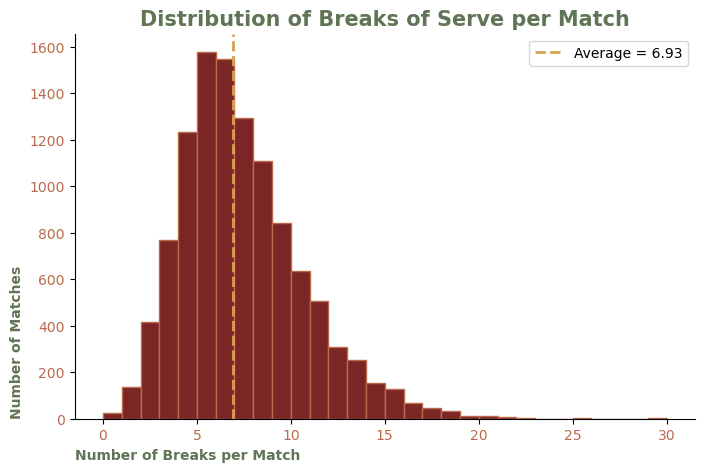

In [93]:
plt.figure(figsize=(8, 5))

plt.hist(
    breaks_per_match["breaks"],
    bins=range(
        int(breaks_per_match["breaks"].min()),
        int(breaks_per_match["breaks"].max()) + 2
    ),
    edgecolor="#BA6A4C",color="#7B2525"
)

plt.axvline(
    average_breaks,
    linestyle="--",
    linewidth=2,
    label=f"Average = {average_breaks:.2f}",color="#D7A052"
)

plt.xlabel("Number of Breaks per Match",loc="left",weight="bold",color="#607456")
plt.ylabel("Number of Matches",loc="bottom",weight="bold",color="#607456")
plt.title("Distribution of Breaks of Serve per Match",fontsize=15,weight="bold",color="#607456")
plt.yticks(color="#BA6A4C")
plt.xticks(color="#BA6A4C")
plt.legend()
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

# Question 18

#### Do seeded players win more often than unseeded players?

In [105]:
seed_data = MatchEventInfo[
    ["match_id", "home_team_seed", "away_team_seed", "winner_code"]
].copy()

seed_data = seed_data[
    seed_data["winner_code"].isin([1, 2])
].drop_duplicates("match_id")

seed_data["home_seeded"] = seed_data["home_team_seed"].notna()
seed_data["away_seeded"] = seed_data["away_team_seed"].notna()

# Keep matches where only one player is seeded
seed_matches = seed_data[
    seed_data["home_seeded"] ^ seed_data["away_seeded"]
].copy()

seed_matches["seeded_won"] = (
    (seed_matches["home_seeded"] & (seed_matches["winner_code"] == 1))
    |
    (seed_matches["away_seeded"] & (seed_matches["winner_code"] == 2))
)

seed_win_rate = seed_matches["seeded_won"].mean() * 100

print("Matches analyzed:", len(seed_matches))
print(f"Seeded player win rate: {seed_win_rate:.2f}%")

Matches analyzed: 4506
Seeded player win rate: 61.74%


Seeded players won 61.74% of matches in which they faced an unseeded player. This suggests that seeded players were more likely to win than unseeded players in the dataset.

# Question 19

#### Which tournament round has the longest average match duration?

In [19]:
round_info = MatchRoundInfo[["match_id", "name", "date"]].copy()
round_info["date"] = pd.to_datetime(round_info["date"],errors="coerce")
round_info = (round_info.sort_values(["match_id", "date"]).drop_duplicates("match_id", keep="last"))

we already created duration_final in question 11 , which contains your cleaned match durations.

In [20]:
round_duration = duration_final[["match_id", "duration_minutes"]].merge(round_info[["match_id", "name"]],on="match_id",how="left")

In [21]:
round_result = (
    round_duration
    .dropna(subset=["name", "duration_minutes"])
    .groupby("name")["duration_minutes"]
    .agg(["count", "mean", "median"])
    .reset_index()
)
round_result = round_result.sort_values( "mean",ascending=False)
round_result

,name,count,mean,median
10,Semifinals,91,113.803297,110.433333
2,Qualification round 2,46,111.356522,113.858333
5,Round of 128,118,111.226554,101.583333
3,Quarterfinal,868,110.346985,103.758333
9,Semifinal,412,110.244782,104.866667
4,Quarterfinals,121,108.219972,105.95
6,Round of 16,1991,107.759945,100.783333
8,Round of 64,194,107.696993,97.266667
0,Final,250,106.061467,101.925
7,Round of 32,3661,105.743809,97.45


In [22]:
round_result.head(1)

,name,count,mean,median
10,Semifinals,91,113.803297,110.433333


The  `Semifinals` had the longest average match duration, with an average duration of approximately 91 minutes.

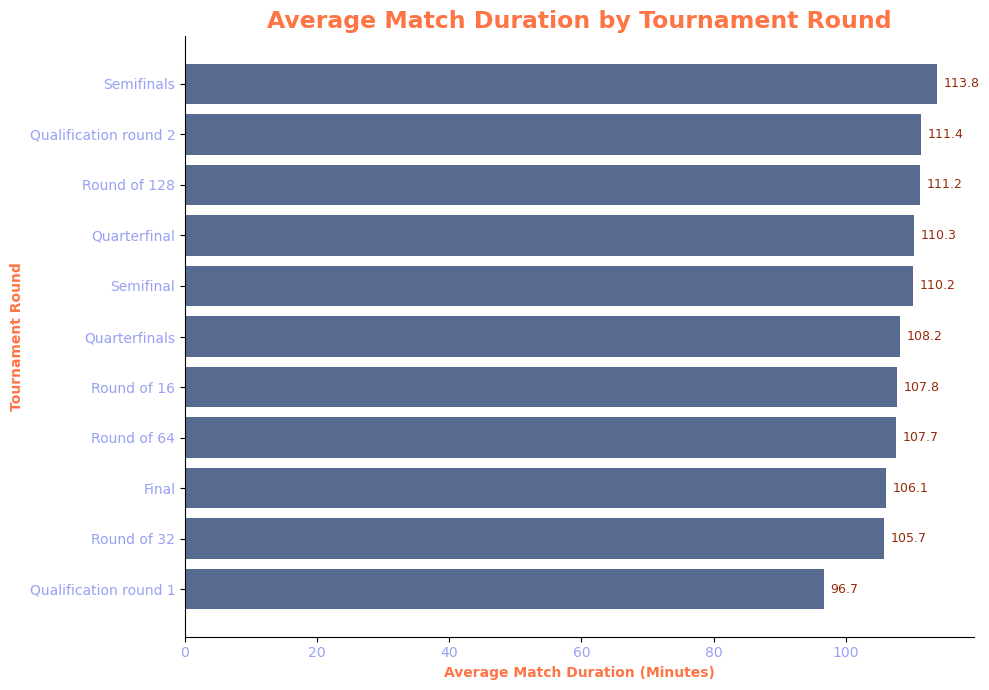

In [ ]:
plot_data = round_result.sort_values("mean",ascending=False).copy()
plt.figure(figsize=(10, 7))

bars = plt.barh(
    plot_data["name"],
    plot_data["mean"],
    color="#576A8F"
)
plt.xlabel("Average Match Duration (Minutes)",weight="bold",color="#FF7444")
plt.ylabel("Tournament Round",weight="bold",color="#FF7444")
plt.title("Average Match Duration by Tournament Round",fontsize=17,weight="bold",color="#FF7444")
plt.xticks(color="#98A1F4")
plt.yticks(color="#98A1F4")

# Display average duration on each bar
for bar in bars:
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}",
        va="center",
        fontsize=9,color="#932B08"
    )
ax = plt.gca()
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Question 20

#### Which group has the better average ranking: left-handed or right-handed players?

In [4]:
hand_players = pd.concat(
    [
        MatchHomeTeamInfo[["player_id", "plays", "current_rank", "date"]],
        MatchAwayTeamInfo[["player_id", "plays", "current_rank", "date"]]
    ],ignore_index=True)
hand_players["date"] = pd.to_datetime(hand_players["date"],errors="coerce")

Get one available playing hand per player and get the latest available ranking after that merge them:

In [5]:
player_hand = (hand_players.dropna(subset=["plays"]).sort_values(["player_id", "date"]).drop_duplicates("player_id", keep="last")[["player_id", "plays"]])
player_rank = (hand_players.dropna(subset=["current_rank"]).sort_values(["player_id", "date"]).drop_duplicates("player_id", keep="last")[["player_id", "current_rank"]])
hand_rank = player_hand.merge(player_rank,on="player_id",how="inner")

In [6]:
hand_rank["plays"].value_counts(dropna=False)

plays
right-handed    999
left-handed     131
Name: count, dtype: int64

In [7]:
hand_result = (
    hand_rank.dropna(subset=["plays", "current_rank"]).groupby("plays")["current_rank"]
    .agg(["count", "mean", "median"]))
hand_result

,count,mean,median
plays,,,
left-handed,131,415.946565,296.0
right-handed,999,460.952953,349.0


In tennis, a lower ranking number is better. So Left-handed players had the better average ranking, because their mean ranking number is lower.

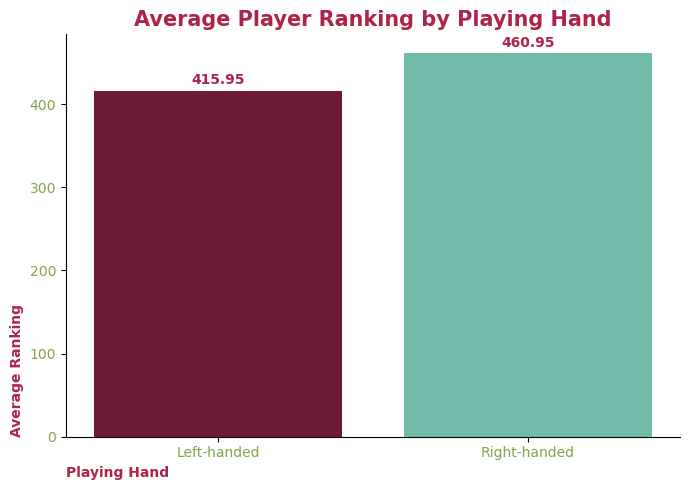

In [9]:
mean_rank = hand_result["mean"].reindex([
    "left-handed",
    "right-handed"
])

plt.figure(figsize=(7, 5))
bars = plt.bar(
    ["Left-handed", "Right-handed"],
    mean_rank.values,
    color=["#6E1A37", "#72BAA9"]
)

plt.xlabel("Playing Hand",weight="bold",color="#AE2448",loc="left")
plt.ylabel("Average Ranking",weight="bold",color="#AE2448",loc="bottom")
plt.title("Average Player Ranking by Playing Hand",fontsize=15,weight="bold",color="#AE2448")
plt.xticks(color="#7B9E40F0")
plt.yticks(color="#7B9E40F0")
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        f"{bar.get_height():.2f}",
        ha="center",
        weight="bold",color="#AE2448"
    )

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()